# Darkness GLM Models For The Cleaned 37-Sensor Dataset

This notebook builds the GLM analysis on top of the cleaned dataset created in `Reprocess OR Confirmation.ipynb`.

## What this notebook does

It fits the four-model ladder we agreed on for **pedestrians** and **cyclists**:

1. **Model 1: Main pooled darkness model**
   - No spatial cluster terms
   - No CCTV
   - No safety
   - Sensor fixed effects
   - Weather, time structure, and lag terms

2. **Model 2: Darkness-by-cluster heterogeneity**
   - Same base model as Model 1
   - Adds `Dark × Cluster`
   - Cluster is only used as an interaction, not as a main effect

3. **Model 3: Darkness-by-CCTV heterogeneity**
   - Same base model as Model 1
   - Adds `Dark × CCTV`
   - CCTV is treated as a secondary contextual moderator, not a main control in the primary model

4. **Model 4: Darkness-by-safety heterogeneity**
   - Same base model as Model 1
   - Adds `Dark × safety`
   - Safety is treated as a secondary contextual moderator, not a main control in the primary model

## Key design choices

- The analysis uses the **cleaned 37-sensor dataset** from the OR workflow.
- The outcome is modelled separately for:
  - `ped`
  - `cyc`
- We focus on the **mixed case hours** used in the OR design:
  - `05:00-05:59`
  - `06:00-06:59`
  - `17:00-17:59`
  - `18:00-18:59`
  - `19:00-19:59`
  - `20:00-20:59`
- We exclude `twilight` rows so the main contrast is **darkness vs daylight**.
- We use **sensor fixed effects** rather than coarse spatial cluster main effects.
- We keep **cluster-robust standard errors by sensor**.

## Interpretation

For each fitted model, the main coefficient of interest is the darkness effect. We convert it to a percent change using:

\[
100 \times (e^{\beta} - 1)
\]

For the interaction models, we also compute darkness effects at meaningful values of the moderator.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')

# ── All data lives in the GLM data/ folder next to this notebook ──────────
DATA_DIR = Path('GLM data')

BASE_PANEL_PATH   = DATA_DIR / 'all_sensor_data_with_locations_and_clusters.csv'
BIG_TABLE_PATH    = DATA_DIR / 'big_table_weather_rain_clusters_safety.csv'
CCTV_PATH         = DATA_DIR / 'sensor_cctv_within_300m_clean37.csv'
SAFETY_PATH       = DATA_DIR / 'sensor_ward_safety_after_dark_2024_clean37.csv'
BUSINESSES_PATH   = DATA_DIR / 'businesses_per_sensor.csv'
STREETLIGHT_PATH  = DATA_DIR / 'sensor_streetlight_freq.csv'

print('DATA_DIR =', DATA_DIR.resolve())
for p in [BASE_PANEL_PATH, BIG_TABLE_PATH, CCTV_PATH, SAFETY_PATH, BUSINESSES_PATH, STREETLIGHT_PATH]:
    status = '\u2713' if p.exists() else '\u2717 MISSING'
    print(f'  {p.name}: {status}')

DATA_DIR = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/GLM data
  all_sensor_data_with_locations_and_clusters.csv: ✓
  big_table_weather_rain_clusters_safety.csv: ✓
  sensor_cctv_within_300m_clean37.csv: ✓
  sensor_ward_safety_after_dark_2024_clean37.csv: ✓
  businesses_per_sensor.csv: ✓
  sensor_streetlight_freq.csv: ✓


## Load And Prepare The Analysis Panel

This section:

- loads the cleaned 37-sensor panel
- merges in hourly weather and rain
- merges in sensor-level CCTV and safety context variables
- creates calendar fields and lag variables
- restricts the estimation sample to:
  - rows classified as `daylight` or `darkness`
  - the mixed OR case hours only

A crucial detail is that the lag variables are created on the **full hourly time series before filtering to mixed hours**, so `lag1` still means the previous hour and `lag24` still means the same hour on the previous day.


In [2]:
panel = pd.read_csv(BASE_PANEL_PATH)
panel['datetime'] = pd.to_datetime(panel['date'], utc=True, errors='coerce')

# ── Weather and rain from the big table ───────────────────────────────────
big_table = pd.read_csv(BIG_TABLE_PATH)
big_table['datetime'] = pd.to_datetime(big_table['datetime'], utc=True, errors='coerce')
weather_rain = (
    big_table[['datetime', 'temp_c', 'wind_ms', 'rain_mm']]
    .drop_duplicates('datetime')
    .dropna(subset=['datetime'])
)
del big_table  # free memory

# ── CCTV and safety from their dedicated files ────────────────────────────
cctv_raw = pd.read_csv(CCTV_PATH)
cctv_id_col = 'sensor_id' if 'sensor_id' in cctv_raw.columns else 'SensorNumber'
cctv = (
    cctv_raw[[cctv_id_col, 'cctv_300m']]
    .drop_duplicates(cctv_id_col)
    .rename(columns={cctv_id_col: 'SensorNumber'})
)

safety_raw = pd.read_csv(SAFETY_PATH)
safety_id_col = 'sensor_id' if 'sensor_id' in safety_raw.columns else 'SensorNumber'
safety_keep = [safety_id_col, 'safety_after_dark_pct']
if 'ward_name' in safety_raw.columns:
    safety_keep.append('ward_name')
if 'safety_scaled' in safety_raw.columns:
    safety_keep.append('safety_scaled')
safety = (
    safety_raw[safety_keep]
    .drop_duplicates(safety_id_col)
    .rename(columns={safety_id_col: 'SensorNumber'})
)

# ── Merge everything onto the panel ───────────────────────────────────────
panel = panel.merge(weather_rain, on='datetime', how='left')
panel = panel.merge(cctv, on='SensorNumber', how='left')
panel = panel.merge(safety, on='SensorNumber', how='left')

panel['rain_mm'] = panel['rain_mm'].fillna(0)
panel['day'] = panel['datetime'].dt.normalize()
panel['hour'] = panel['datetime'].dt.hour.astype(int)
panel['dow'] = panel['datetime'].dt.dayofweek.astype(int)
panel['month'] = panel['datetime'].dt.month.astype(int)
panel['year'] = panel['datetime'].dt.year.astype(int)
panel['is_weekend'] = panel['dow'].isin([5, 6]).astype(int)

panel = panel.sort_values(['SensorNumber', 'datetime']).reset_index(drop=True)

panel['ped_lag1'] = panel.groupby('SensorNumber')['ped'].shift(1)
panel['ped_lag24'] = panel.groupby('SensorNumber')['ped'].shift(24)
panel['cyc_lag1'] = panel.groupby('SensorNumber')['cyc'].shift(1)
panel['cyc_lag24'] = panel.groupby('SensorNumber')['cyc'].shift(24)

mixed_case_hours = [5, 6, 17, 18, 19, 20]
analysis_df = panel.loc[
    panel['light_class'].isin(['daylight', 'darkness'])
    & panel['hour'].isin(mixed_case_hours)
].copy()

analysis_df['Cluster'] = pd.Categorical(
    analysis_df['Cluster'],
    categories=['Central', 'East', 'Outlier']
)

sensor_context = (
    analysis_df[['SensorNumber', 'Cluster', 'cctv_300m', 'safety_after_dark_pct']]
    .drop_duplicates('SensorNumber')
    .sort_values('SensorNumber')
    .reset_index(drop=True)
)

cctv_mean = sensor_context['cctv_300m'].mean(skipna=True)
cctv_std = sensor_context['cctv_300m'].std(skipna=True)
safety_mean = sensor_context['safety_after_dark_pct'].mean(skipna=True)
safety_std = sensor_context['safety_after_dark_pct'].std(skipna=True)

analysis_df['cctv_z'] = (analysis_df['cctv_300m'] - cctv_mean) / cctv_std
analysis_df['safety_z'] = (analysis_df['safety_after_dark_pct'] - safety_mean) / safety_std

print('Full merged panel shape:', panel.shape)
print('Analysis sample shape :', analysis_df.shape)
print('Cleaned sensors used  :', analysis_df['SensorNumber'].nunique())
print('\nLight classes in analysis sample:')
print(analysis_df['light_class'].value_counts(dropna=False).to_string())
print('\nCluster counts (sensor-level):')
print(sensor_context['Cluster'].value_counts(dropna=False).to_string())
print('\nMissing rates in merged hourly panel:')
print(panel[['temp_c', 'wind_ms', 'rain_mm', 'cctv_300m', 'safety_after_dark_pct']].isna().mean().to_string())
print('\nContext coverage across cleaned sensors:')
print(sensor_context[['cctv_300m', 'safety_after_dark_pct']].notna().sum().to_string())

sensor_context.head(10)

Full merged panel shape: (325008, 30)
Analysis sample shape : (71311, 32)
Cleaned sensors used  : 37

Light classes in analysis sample:
light_class
darkness    36358
daylight    34953

Cluster counts (sensor-level):
Cluster
East       20
Central     9
Outlier     8

Missing rates in merged hourly panel:
temp_c                   0.063980
wind_ms                  0.061589
rain_mm                  0.000000
cctv_300m                0.000000
safety_after_dark_pct    0.000000

Context coverage across cleaned sensors:
cctv_300m                37
safety_after_dark_pct    37


,SensorNumber,Cluster,cctv_300m,safety_after_dark_pct
0,1,Central,52,53.5
1,2,Central,53,53.5
2,4,Central,183,53.5
3,5,Central,49,53.5
4,7,Outlier,0,81.9
5,8,Outlier,0,81.9
6,9,Outlier,0,81.9
7,11,Outlier,7,75.6
8,13,Central,55,53.5
9,14,Central,8,53.5


## Helper Functions

These helpers:

- fit the negative binomial GLM with cluster-robust standard errors by sensor
- build compact summary tables for the fitted models
- calculate percent darkness effects
- calculate moderator-specific darkness effects for the heterogeneity models


In [3]:
def fit_nb_glm(data, outcome, rhs, required_cols, label):
    cols = list(dict.fromkeys(required_cols + [outcome, 'SensorNumber']))
    model_df = data[cols].dropna().copy()

    formula = f"{outcome} ~ {rhs}"
    result = smf.glm(
        formula=formula,
        data=model_df,
        family=sm.families.NegativeBinomial(),
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': model_df['SensorNumber'].values},
    )

    dispersion = result.pearson_chi2 / result.df_resid
    info = {
        'label': label,
        'outcome': outcome,
        'n_rows': len(model_df),
        'n_sensors': model_df['SensorNumber'].nunique(),
        'dispersion': dispersion,
        'formula': formula,
    }
    return result, model_df, info


def coef_percent_change(beta):
    return 100 * (np.exp(beta) - 1)


def term_row(result, term, label=None):
    ci = result.conf_int()
    return {
        'term': label or term,
        'coef': result.params.get(term, np.nan),
        'std_err': result.bse.get(term, np.nan),
        'p_value': result.pvalues.get(term, np.nan),
        'ci_low': ci.loc[term, 0] if term in ci.index else np.nan,
        'ci_high': ci.loc[term, 1] if term in ci.index else np.nan,
        'percent_change': coef_percent_change(result.params.get(term, np.nan)) if term in result.params.index else np.nan,
    }


def find_interaction_term(result, contains_all):
    for name in result.params.index:
        if all(token in name for token in contains_all):
            return name
    return None


def cluster_darkness_effects(result):
    dark_term = 'Dark'
    east_term = find_interaction_term(result, ['Dark:C(Cluster', 'East'])
    outlier_term = find_interaction_term(result, ['Dark:C(Cluster', 'Outlier'])

    rows = []
    for cluster_name, extra_term in [('Central', None), ('East', east_term), ('Outlier', outlier_term)]:
        beta = result.params[dark_term]
        if extra_term is not None:
            beta += result.params[extra_term]
        rows.append({
            'cluster': cluster_name,
            'dark_coef': beta,
            'dark_percent_change': coef_percent_change(beta),
        })
    return pd.DataFrame(rows)


def moderator_darkness_effects(result, interaction_term, moderator_label):
    dark_beta = result.params['Dark']
    int_beta = result.params[interaction_term]
    rows = []
    for value, label in [(-1.0, f'{moderator_label} = -1 SD'), (0.0, f'{moderator_label} = mean'), (1.0, f'{moderator_label} = +1 SD')]:
        beta = dark_beta + int_beta * value
        rows.append({
            moderator_label: label,
            'dark_coef': beta,
            'dark_percent_change': coef_percent_change(beta),
        })
    return pd.DataFrame(rows)


def print_model_banner(title):
    display(Markdown(f'## {title}'))


## Model 1: Main Pooled Darkness Model

This is the main model for the report question.

### Included
- `Dark`
- outcome-specific lag terms (`lag1`, `lag24`)
- `C(hour)`
- `C(dow)`
- `C(month)`
- `temp_c`
- `wind_ms`
- `rain_mm`
- `C(SensorNumber)` sensor fixed effects

### Excluded
- cluster as a main effect
- CCTV
- safety

This gives the cleanest estimate of the average within-sensor darkness effect after adjusting for regular traffic structure, weather, and short-run temporal dependence.


In [4]:
model_results = {}

model_1_specs = {
    'ped': {
        'rhs': 'Dark + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
    'cyc': {
        'rhs': 'Dark + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
}

for outcome, spec in model_1_specs.items():
    result, model_df, info = fit_nb_glm(
        analysis_df,
        outcome=outcome,
        rhs=spec['rhs'],
        required_cols=spec['required_cols'],
        label='Model 1',
    )
    model_results[('Model 1', outcome)] = {'result': result, 'data': model_df, 'info': info}

    display(Markdown(f"### Model 1 | {outcome}"))
    display(pd.DataFrame([info]))
    display(pd.DataFrame([term_row(result, 'Dark', 'Dark')]))
    display(result.summary())


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 1 | ped

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 1,ped,70836,37,0.923007,ped ~ Dark + ped_lag1 + ped_lag24 + C(hour) + ...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark,-0.404897,0.066961,1.477731e-09,-0.536138,-0.273656,-33.295445


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    ped   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70771
Model Family:        NegativeBinomial   Df Model:                           64
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.2244e+05
Date:                Mon, 06 Apr 2026   Deviance:                       45354.
Time:                        14:54:57   Pearson chi2:                 6.53e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.8485
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  3.5329      0.287     12.316      0.000       2.971       4.095
C(hour)[T.6]               0.8276      0.050     16.718      0.000       0.731       0.925
C(hour)[T.17]              1.5928      0.142     11.204      0.000       1.314       1.871
C(hour)[T.18]              1.4835      0.133     11.195      0.000       1.224       1.743
C(hour)[T.19]              1.3279      0.124     10.729      0.000       1.085       1.570
C(hour)[T.20]              1.1395      0.123      9.269      0.000       0.899       1.380
C(dow)[T.1]                0.0436      0.019      2.357      0.018       0.007       0.080
C(dow)[T.2]                0.0619      0.018      3.383      0.001       0.026       0.098
C(dow)[T.3]                0.0362      0.020      1.788      0.074      -0.003       0.076
C(dow)[T.4]                0.0499      0.023      2.170      0.030       0.005       0.095
C(dow)[T.5]               -0.2223      0.031     -7.228      0.000      -0.283      -0.162
C(dow)[T.6]               -0.4291      0.034    -12.452      0.000      -0.497      -0.362
C(month)[T.2]              0.0413      0.042      0.988      0.323      -0.041       0.123
C(month)[T.3]              0.2022      0.057      3.562      0.000       0.091       0.313
C(month)[T.4]              0.2485      0.048      5.179      0.000       0.154       0.343
C(month)[T.5]              0.3259      0.056      5.842      0.000       0.217       0.435
C(month)[T.6]              0.3047      0.057      5.388      0.000       0.194       0.415
C(month)[T.7]              0.2997      0.056      5.361      0.000       0.190       0.409
C(month)[T.8]              0.2436      0.055      4.442      0.000       0.136       0.351
C(month)[T.9]              0.3753      0.071      5.256      0.000       0.235       0.515
C(month)[T.10]             0.2438      0.058      4.180      0.000       0.129       0.358
C(month)[T.11]             0.0614      0.095      0.645      0.519      -0.125       0.248
C(month)[T.12]             0.0501      0.156      0.322      0.748      -0.255       0.355
C(SensorNumber)[T.2]      -0.1783      0.037     -4.780      0.000      -0.251      -0.105
C(SensorNumber)[T.4]      -0.9450      0.126     -7.527      0.000      -1.191      -0.699
C(SensorNumber)[T.5]      -0.1361      0.119     -1.139      0.255      -0.370       0.098
C(SensorNumber)[T.7]      -0.3904      0.099     -3.924      0.000      -0.585      -0.195
C(SensorNumber)[T.8]      -2.2326      0.334     -6.691      0.000      -2.887      -1.579
C(SensorNumber)[T.9]      -4.0423      0.358    -11.283      0.000      -4.745      -3.340
C(SensorNumber)[T.11]     -0.6468      0.239     -2.707      0.007      -1.115      -0.179
C(SensorNumber)[T.13]     -0.8223      0.251     -3.283      0.001      -1.313  

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 1 | cyc

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 1,cyc,70836,37,1.091434,cyc ~ Dark + cyc_lag1 + cyc_lag24 + C(hour) + ...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark,-0.040469,0.053122,0.446167,-0.144586,0.063647,-3.966127


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cyc   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70771
Model Family:        NegativeBinomial   Df Model:                           64
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4877e+05
Date:                Mon, 06 Apr 2026   Deviance:                       43518.
Time:                        14:55:10   Pearson chi2:                 7.72e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.7079
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.1666      0.196     11.077      0.000       1.783       2.550
C(hour)[T.6]               0.6340      0.056     11.312      0.000       0.524       0.744
C(hour)[T.17]              1.0118      0.098     10.301      0.000       0.819       1.204
C(hour)[T.18]              0.8662      0.095      9.151      0.000       0.681       1.052
C(hour)[T.19]              0.7588      0.091      8.303      0.000       0.580       0.938
C(hour)[T.20]              0.6523      0.082      7.976      0.000       0.492       0.813
C(dow)[T.1]                0.0378      0.022      1.737      0.082      -0.005       0.080
C(dow)[T.2]                0.0295      0.034      0.869      0.385      -0.037       0.096
C(dow)[T.3]               -0.0108      0.031     -0.351      0.725      -0.071       0.049
C(dow)[T.4]               -0.1147      0.024     -4.694      0.000      -0.163      -0.067
C(dow)[T.5]               -0.4963      0.042    -11.729      0.000      -0.579      -0.413
C(dow)[T.6]               -0.5490      0.044    -12.445      0.000      -0.635      -0.463
C(month)[T.2]              0.1084      0.033      3.309      0.001       0.044       0.173
C(month)[T.3]              0.1898      0.053      3.611      0.000       0.087       0.293
C(month)[T.4]              0.2466      0.051      4.880      0.000       0.148       0.346
C(month)[T.5]              0.2733      0.058      4.715      0.000       0.160       0.387
C(month)[T.6]              0.3023      0.062      4.868      0.000       0.181       0.424
C(month)[T.7]              0.2759      0.065      4.257      0.000       0.149       0.403
C(month)[T.8]              0.2547      0.065      3.906      0.000       0.127       0.382
C(month)[T.9]              0.4318      0.072      5.989      0.000       0.290       0.573
C(month)[T.10]             0.4246      0.067      6.294      0.000       0.292       0.557
C(month)[T.11]             0.3362      0.083      4.063      0.000       0.174       0.498
C(month)[T.12]             0.2374      0.096      2.465      0.014       0.049       0.426
C(SensorNumber)[T.2]      -0.0734      0.007     -9.903      0.000      -0.088      -0.059
C(SensorNumber)[T.4]      -0.2857      0.026    -11.120      0.000      -0.336      -0.235
C(SensorNumber)[T.5]      -0.2062      0.094     -2.205      0.027      -0.390      -0.023
C(SensorNumber)[T.7]      -1.2096      0.180     -6.711      0.000      -1.563      -0.856
C(SensorNumber)[T.8]      -1.8626      0.196     -9.519      0.000      -2.246      -1.479
C(SensorNumber)[T.9]      -2.0916      0.192    -10.884      0.000      -2.468      -1.715
C(SensorNumber)[T.11]     -0.4008      0.128     -3.125      0.002      -0.652      -0.149
C(SensorNumber)[T.13]     -0.6988      0.139     -5.017      0.000      -0.972  

## Model 2: Darkness-By-Cluster Heterogeneity

This model keeps the same core structure as Model 1 but adds a **darkness-by-cluster interaction**.

### Important modelling point
Because we are already using sensor fixed effects, we **do not** include a cluster main effect. Cluster is time-invariant at the sensor level, so the main effect is absorbed by `C(SensorNumber)`.

What we can still estimate is whether the **darkness effect differs across clusters**.


In [5]:
model_2_specs = {
    'ped': {
        'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
        'required_cols': ['Dark', 'Cluster', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
    'cyc': {
        'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
        'required_cols': ['Dark', 'Cluster', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
}

for outcome, spec in model_2_specs.items():
    result, model_df, info = fit_nb_glm(
        analysis_df,
        outcome=outcome,
        rhs=spec['rhs'],
        required_cols=spec['required_cols'],
        label='Model 2',
    )
    model_results[('Model 2', outcome)] = {'result': result, 'data': model_df, 'info': info}

    display(Markdown(f"### Model 2 | {outcome}"))
    display(pd.DataFrame([info]))
    display(cluster_darkness_effects(result))
    display(result.summary())


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 2 | ped

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 2,ped,70836,37,0.919924,"ped ~ Dark + Dark:C(Cluster, Treatment(referen..."


,cluster,dark_coef,dark_percent_change
0,Central,-0.394529,-32.600267
1,East,-0.318406,-27.269252
2,Outlier,-0.659371,-48.282326


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    ped   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70769
Model Family:        NegativeBinomial   Df Model:                           66
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.2231e+05
Date:                Mon, 06 Apr 2026   Deviance:                       45096.
Time:                        14:55:26   Pearson chi2:                 6.51e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.8491
Covariance Type:              cluster                                         
==============================================================================================================================
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      3.5269      0.274     12.872      0.000       2.990       4.064
C(hour)[T.6]                                                   0.8264      0.049     16.783      0.000       0.730       0.923
C(hour)[T.17]                                                  1.5891      0.137     11.586      0.000       1.320       1.858
C(hour)[T.18]                                                  1.4805      0.130     11.404      0.000       1.226       1.735
C(hour)[T.19]                                                  1.3257      0.122     10.843      0.000       1.086       1.565
C(hour)[T.20]                                                  1.1407      0.121      9.396      0.000       0.903       1.379
C(dow)[T.1]                                                    0.0437      0.017      2.517      0.012       0.010       0.078
C(dow)[T.2]                                                    0.0621      0.017      3.627      0.000       0.029       0.096
C(dow)[T.3]                                                    0.0357      0.019      1.890      0.059      -0.001       0.073
C(dow)[T.4]                                                    0.0488      0.022      2.204      0.028       0.005       0.092
C(dow)[T.5]                                                   -0.2235      0.029     -7.658      0.000      -0.281      -0.166
C(dow)[T.6]                                                   -0.4299      0.033    -13.015      0.000      -0.495      -0.365
C(month)[T.2]                                                  0.0386      0.043      0.906      0.365      -0.045       0.122
C(month)[T.3]                                                  0.2010      0.057      3.505      0.000       0.089       0.313
C(month)[T.4]                                                  0.2480      0.049      5.097      0.000       0.153       0.343
C(month)[T.5]                                                  0.3250      0.057      5.673      0.000       0.213       0.437
C(month)[T.6]                                                  0.3050      0.057      5.321      0.000       0.193       0.417
C(month)[T.7]                                                  0.3003      0.057      5.309      0.000       0.189       0.411
C(month)[T.8]                                                  0.2453      0.056      4.380      0.000       0.136       0.355
C(month)[T.9]                                                  0.3776      0.075      5.052      0.000       0.231       0.524
C(month)[T.10]                                                 0.2407      0.059      4.067      0.000       0.125       0.357
C(month)[T.11]                     

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 2 | cyc

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 2,cyc,70836,37,1.061807,"cyc ~ Dark + Dark:C(Cluster, Treatment(referen..."


,cluster,dark_coef,dark_percent_change
0,Central,-0.228968,-20.464608
1,East,-0.015947,-1.582085
2,Outlier,0.185691,20.405013


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cyc   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70769
Model Family:        NegativeBinomial   Df Model:                           66
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4863e+05
Date:                Mon, 06 Apr 2026   Deviance:                       43243.
Time:                        14:55:40   Pearson chi2:                 7.51e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.7090
Covariance Type:              cluster                                         
==============================================================================================================================
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      2.2900      0.196     11.709      0.000       1.907       2.673
C(hour)[T.6]                                                   0.6442      0.056     11.501      0.000       0.534       0.754
C(hour)[T.17]                                                  1.0426      0.095     11.031      0.000       0.857       1.228
C(hour)[T.18]                                                  0.8891      0.093      9.511      0.000       0.706       1.072
C(hour)[T.19]                                                  0.7773      0.092      8.482      0.000       0.598       0.957
C(hour)[T.20]                                                  0.6678      0.085      7.878      0.000       0.502       0.834
C(dow)[T.1]                                                    0.0454      0.020      2.270      0.023       0.006       0.085
C(dow)[T.2]                                                    0.0409      0.031      1.318      0.188      -0.020       0.102
C(dow)[T.3]                                                    0.0002      0.029      0.007      0.995      -0.056       0.057
C(dow)[T.4]                                                   -0.1046      0.024     -4.407      0.000      -0.151      -0.058
C(dow)[T.5]                                                   -0.4891      0.043    -11.503      0.000      -0.572      -0.406
C(dow)[T.6]                                                   -0.5497      0.044    -12.583      0.000      -0.635      -0.464
C(month)[T.2]                                                  0.1069      0.032      3.344      0.001       0.044       0.170
C(month)[T.3]                                                  0.1893      0.052      3.657      0.000       0.088       0.291
C(month)[T.4]                                                  0.2428      0.050      4.842      0.000       0.145       0.341
C(month)[T.5]                                                  0.2681      0.058      4.613      0.000       0.154       0.382
C(month)[T.6]                                                  0.2986      0.062      4.797      0.000       0.177       0.421
C(month)[T.7]                                                  0.2715      0.065      4.183      0.000       0.144       0.399
C(month)[T.8]                                                  0.2491      0.065      3.824      0.000       0.121       0.377
C(month)[T.9]                                                  0.4281      0.072      5.976      0.000       0.288       0.568
C(month)[T.10]                                                 0.4192      0.067      6.291      0.000       0.289       0.550
C(month)[T.11]                     

## Model 3: Darkness-By-CCTV Heterogeneity

This model asks whether the darkness effect is different at sensors with higher or lower CCTV availability.

### Important modelling point
As with cluster, CCTV is time-invariant at the sensor level. Because we use sensor fixed effects, we do **not** include CCTV as a main effect. We only include the interaction with `Dark`.

### Coverage note
CCTV has been recalculated directly on the cleaned 37-sensor panel using the raw CCTV file and the same counting logic as the `shav-work` pipeline, so this model now runs on the full cleaned sensor set.


In [6]:
analysis_cctv = analysis_df.dropna(subset=['cctv_z']).copy()
print('CCTV model sensors:', analysis_cctv['SensorNumber'].nunique())
print('CCTV model rows   :', len(analysis_cctv))

model_3_specs = {
    'ped': {
        'rhs': 'Dark + Dark:cctv_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'cctv_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
    'cyc': {
        'rhs': 'Dark + Dark:cctv_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'cctv_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
}

for outcome, spec in model_3_specs.items():
    result, model_df, info = fit_nb_glm(
        analysis_cctv,
        outcome=outcome,
        rhs=spec['rhs'],
        required_cols=spec['required_cols'],
        label='Model 3',
    )
    model_results[('Model 3', outcome)] = {'result': result, 'data': model_df, 'info': info}

    interaction_term = 'Dark:cctv_z'
    display(Markdown(f"### Model 3 | {outcome}"))
    display(pd.DataFrame([info]))
    display(pd.DataFrame([
        term_row(result, 'Dark', 'Dark (mean CCTV)'),
        term_row(result, interaction_term, 'Dark × CCTV z-score'),
    ]))
    display(moderator_darkness_effects(result, interaction_term, 'CCTV'))
    display(result.summary())


CCTV model sensors: 37
CCTV model rows   : 71311


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 3 | ped

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 3,ped,70836,37,0.922099,ped ~ Dark + Dark:cctv_z + ped_lag1 + ped_lag2...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark (mean CCTV),-0.405131,0.065911,7.913928e-10,-0.534313,-0.275948,-33.311026
1,Dark × CCTV z-score,0.011319,0.175062,9.484452e-01,-0.331795,0.354434,1.138367


...

### Model 3 | cyc

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 3,cyc,70836,37,1.09096,cyc ~ Dark + Dark:cctv_z + cyc_lag1 + cyc_lag2...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark (mean CCTV),-0.040264,0.053009,0.447508,-0.144159,0.063631,-3.946427
1,Dark × CCTV z-score,-0.004470,0.060424,0.941027,-0.122900,0.113959,-0.446018


,CCTV,dark_coef,dark_percent_change
0,CCTV = -1 SD,-0.035794,-3.516092
1,CCTV = mean,-0.040264,-3.946427
2,CCTV = +1 SD,-0.044734,-4.374843


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cyc   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70770
Model Family:        NegativeBinomial   Df Model:                           65
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4877e+05
Date:                Mon, 06 Apr 2026   Deviance:                       43518.
Time:                        14:56:08   Pearson chi2:                 7.72e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.7079
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.1679      0.201     10.779      0.000       1.774       2.562
C(hour)[T.6]               0.6341      0.057     11.204      0.000       0.523       0.745
C(hour)[T.17]              1.0125      0.099     10.218      0.000       0.818       1.207
C(hour)[T.18]              0.8666      0.096      9.067      0.000       0.679       1.054
C(hour)[T.19]              0.7591      0.093      8.200      0.000       0.578       0.941
C(hour)[T.20]              0.6527      0.084      7.791      0.000       0.489       0.817
C(dow)[T.1]                0.0380      0.021      1.833      0.067      -0.003       0.079
C(dow)[T.2]                0.0299      0.033      0.912      0.362      -0.034       0.094
C(dow)[T.3]               -0.0105      0.030     -0.348      0.728      -0.069       0.049
C(dow)[T.4]               -0.1144      0.024     -4.797      0.000      -0.161      -0.068
C(dow)[T.5]               -0.4961      0.042    -11.753      0.000      -0.579      -0.413
C(dow)[T.6]               -0.5489      0.044    -12.442      0.000      -0.635      -0.462
C(month)[T.2]              0.1083      0.033      3.312      0.001       0.044       0.172
C(month)[T.3]              0.1898      0.052      3.616      0.000       0.087       0.293
C(month)[T.4]              0.2465      0.051      4.874      0.000       0.147       0.346
C(month)[T.5]              0.2732      0.058      4.697      0.000       0.159       0.387
C(month)[T.6]              0.3022      0.062      4.853      0.000       0.180       0.424
C(month)[T.7]              0.2757      0.065      4.239      0.000       0.148       0.403
C(month)[T.8]              0.2546      0.065      3.887      0.000       0.126       0.383
C(month)[T.9]              0.4317      0.072      5.986      0.000       0.290       0.573
C(month)[T.10]             0.4245      0.067      6.290      0.000       0.292       0.557
C(month)[T.11]             0.3360      0.082      4.082      0.000       0.175       0.497
C(month)[T.12]             0.2371      0.096      2.471      0.013       0.049       0.425
C(SensorNumber)[T.2]      -0.0734      0.007     -9.819      0.000      -0.088      -0.059
C(SensorNumber)[T.4]      -0.2802      0.074     -3.764      0.000      -0.426      -0.134
C(SensorNumber)[T.5]      -0.2069      0.097     -2.143      0.032      -0.396      -0.018
C(SensorNumber)[T.7]      -1.2131      0.198     -6.136      0.000      -1.601      -0.826
C(SensorNumber)[T.8]      -1.8659      0.211     -8.851      0.000      -2.279      -1.453
C(SensorNumber)[T.9]      -2.0946      0.205    -10.203      0.000      -2.497      -1.692
C(SensorNumber)[T.11]     -0.4038      0.145     -2.791      0.005      -0.687      -0.120
C(SensorNumber)[T.13]     -0.6997      0.143     -4.907      0.000      -0.979  

## Model 4: Darkness-By-Safety Heterogeneity

This model asks whether the darkness effect is different at sensors in wards with higher or lower perceived after-dark safety.

### Important modelling point
Safety is also time-invariant at the sensor level, so we again include it only through the interaction with `Dark`.

### Interpretation note
This is a **secondary exploratory model**. The safety measure is a ward-level survey variable, not an hourly observed safety measure, so it should not be treated as the primary darkness control. The ward assignments have been rebuilt for all 37 cleaned sensors from the raw ward boundary and survey files.


In [7]:
analysis_safety = analysis_df.dropna(subset=['safety_z']).copy()
print('Safety model sensors:', analysis_safety['SensorNumber'].nunique())
print('Safety model rows   :', len(analysis_safety))

model_4_specs = {
    'ped': {
        'rhs': 'Dark + Dark:safety_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'safety_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
    'cyc': {
        'rhs': 'Dark + Dark:safety_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        'required_cols': ['Dark', 'safety_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
    },
}

for outcome, spec in model_4_specs.items():
    result, model_df, info = fit_nb_glm(
        analysis_safety,
        outcome=outcome,
        rhs=spec['rhs'],
        required_cols=spec['required_cols'],
        label='Model 4',
    )
    model_results[('Model 4', outcome)] = {'result': result, 'data': model_df, 'info': info}

    interaction_term = 'Dark:safety_z'
    display(Markdown(f"### Model 4 | {outcome}"))
    display(pd.DataFrame([info]))
    display(pd.DataFrame([
        term_row(result, 'Dark', 'Dark (mean safety)'),
        term_row(result, interaction_term, 'Dark × safety z-score'),
    ]))
    display(moderator_darkness_effects(result, interaction_term, 'Safety'))
    display(result.summary())


Safety model sensors: 37
Safety model rows   : 71311


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 4 | ped

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 4,ped,70836,37,0.878078,ped ~ Dark + Dark:safety_z + ped_lag1 + ped_la...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark (mean safety),-0.420142,0.070054,2.005392e-09,-0.557447,-0.282838,-34.304674
1,Dark × safety z-score,-0.224761,0.159938,1.599313e-01,-0.538233,0.088711,-20.129294


...

### Model 4 | cyc

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 4,cyc,70836,37,1.087717,cyc ~ Dark + Dark:safety_z + cyc_lag1 + cyc_la...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,Dark (mean safety),-0.042169,0.045641,0.355519,-0.131624,0.047285,-4.129245
1,Dark × safety z-score,-0.262304,0.068227,0.000121,-0.396026,-0.128582,-23.072290


,Safety,dark_coef,dark_percent_change
0,Safety = -1 SD,0.220135,24.624474
1,Safety = mean,-0.042169,-4.129245
2,Safety = +1 SD,-0.304473,-26.248824


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cyc   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70770
Model Family:        NegativeBinomial   Df Model:                           65
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4831e+05
Date:                Mon, 06 Apr 2026   Deviance:                       42594.
Time:                        14:56:34   Pearson chi2:                 7.70e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.7117
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.2194      0.194     11.464      0.000       1.840       2.599
C(hour)[T.6]               0.6441      0.055     11.619      0.000       0.535       0.753
C(hour)[T.17]              1.0214      0.094     10.838      0.000       0.837       1.206
C(hour)[T.18]              0.8784      0.093      9.484      0.000       0.697       1.060
C(hour)[T.19]              0.7689      0.090      8.509      0.000       0.592       0.946
C(hour)[T.20]              0.6629      0.082      8.092      0.000       0.502       0.823
C(dow)[T.1]                0.0443      0.022      1.984      0.047       0.001       0.088
C(dow)[T.2]                0.0343      0.033      1.028      0.304      -0.031       0.100
C(dow)[T.3]               -0.0054      0.030     -0.177      0.860      -0.065       0.054
C(dow)[T.4]               -0.1092      0.024     -4.513      0.000      -0.157      -0.062
C(dow)[T.5]               -0.4928      0.042    -11.743      0.000      -0.575      -0.411
C(dow)[T.6]               -0.5474      0.044    -12.556      0.000      -0.633      -0.462
C(month)[T.2]              0.1061      0.033      3.256      0.001       0.042       0.170
C(month)[T.3]              0.1875      0.053      3.539      0.000       0.084       0.291
C(month)[T.4]              0.2413      0.051      4.737      0.000       0.141       0.341
C(month)[T.5]              0.2663      0.058      4.584      0.000       0.152       0.380
C(month)[T.6]              0.2977      0.062      4.791      0.000       0.176       0.420
C(month)[T.7]              0.2720      0.065      4.205      0.000       0.145       0.399
C(month)[T.8]              0.2492      0.065      3.838      0.000       0.122       0.377
C(month)[T.9]              0.4288      0.071      6.036      0.000       0.290       0.568
C(month)[T.10]             0.4247      0.069      6.166      0.000       0.290       0.560
C(month)[T.11]             0.3348      0.085      3.948      0.000       0.169       0.501
C(month)[T.12]             0.2361      0.098      2.411      0.016       0.044       0.428
C(SensorNumber)[T.2]      -0.0757      0.008     -9.655      0.000      -0.091      -0.060
C(SensorNumber)[T.4]      -0.2952      0.026    -11.517      0.000      -0.345      -0.245
C(SensorNumber)[T.5]      -0.2178      0.092     -2.365      0.018      -0.398      -0.037
C(SensorNumber)[T.7]      -0.9322      0.196     -4.759      0.000      -1.316      -0.548
C(SensorNumber)[T.8]      -1.6493      0.201     -8.218      0.000      -2.043      -1.256
C(SensorNumber)[T.9]      -1.9330      0.189    -10.253      0.000      -2.302      -1.563
C(SensorNumber)[T.11]     -0.1572      0.144     -1.093      0.274      -0.439       0.125
C(SensorNumber)[T.13]     -0.7228      0.137     -5.293      0.000      -0.990  

## Compare The Four Models

This final section creates compact comparison tables so the main darkness estimates can be compared across models and across transport modes.


In [8]:
comparison_rows = []
for (model_name, outcome), payload in model_results.items():
    result = payload['result']
    info = payload['info']
    row = {
        'model': model_name,
        'outcome': outcome,
        'n_rows': info['n_rows'],
        'n_sensors': info['n_sensors'],
        'dispersion': info['dispersion'],
        'dark_coef': result.params.get('Dark', np.nan),
        'dark_percent_change': coef_percent_change(result.params.get('Dark', np.nan)),
        'dark_p_value': result.pvalues.get('Dark', np.nan),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(['outcome', 'model']).reset_index(drop=True)
display(comparison_df)

comparison_path = DATA_DIR / 'darkness_glm_model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print('Saved model comparison table to:', comparison_path)

,model,outcome,n_rows,n_sensors,dispersion,dark_coef,dark_percent_change,dark_p_value
0,Model 1,cyc,70836,37,1.091434,-0.040469,-3.966127,4.461672e-01
1,Model 2,cyc,70836,37,1.061807,-0.228968,-20.464608,1.468299e-03
2,Model 3,cyc,70836,37,1.090960,-0.040264,-3.946427,4.475082e-01
3,Model 4,cyc,70836,37,1.087717,-0.042169,-4.129245,3.555192e-01
4,Model 1,ped,70836,37,0.923007,-0.404897,-33.295445,1.477731e-09
5,Model 2,ped,70836,37,0.919924,-0.394529,-32.600267,2.296114e-02
6,Model 3,ped,70836,37,0.922099,-0.405131,-33.311026,7.913928e-10
7,Model 4,ped,70836,37,0.878078,-0.420142,-34.304674,2.005392e-09


Saved model comparison table to: GLM data/darkness_glm_model_comparison.csv


In [9]:
def linear_combo_summary(result, weights):
    params = result.params
    cov = result.cov_params()
    idx = list(params.index)
    w = np.zeros(len(idx))
    for name, value in weights.items():
        if name in idx:
            w[idx.index(name)] = value
    est = float(np.dot(w, params.values))
    var = float(w @ cov.values @ w)
    se = float(np.sqrt(max(var, 0)))
    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se
    return {
        'coef': est,
        'pct': coef_percent_change(est),
        'ci_low_pct': coef_percent_change(ci_low),
        'ci_high_pct': coef_percent_change(ci_high),
    }


def get_cluster_term(result, label):
    for name in result.params.index:
        if 'Dark:C(Cluster' in name and label in name:
            return name
    return None


fig_dir = Path('.')

# Figure 1 should only compare directly comparable darkness effects.
# Model 2 is omitted because its Dark term is the reference-cluster effect,
# not a pooled city-wide effect.
main_effect_rows = []
for model_name in ['Model 1', 'Model 3', 'Model 4']:
    for outcome in ['ped', 'cyc']:
        result = model_results[(model_name, outcome)]['result']
        stats = linear_combo_summary(result, {'Dark': 1.0})
        main_effect_rows.append({
            'model': model_name,
            'outcome': 'Pedestrians' if outcome == 'ped' else 'Cyclists',
            **stats,
        })
main_effect_df = pd.DataFrame(main_effect_rows)

cyclist_cluster_rows = []
result = model_results[('Model 2', 'cyc')]['result']
for cluster_name in ['Central', 'East', 'Outlier']:
    weights = {'Dark': 1.0}
    if cluster_name == 'East':
        weights[get_cluster_term(result, 'East')] = 1.0
    elif cluster_name == 'Outlier':
        weights[get_cluster_term(result, 'Outlier')] = 1.0
    stats = linear_combo_summary(result, weights)
    cyclist_cluster_rows.append({
        'cluster': cluster_name,
        **stats,
    })
cyclist_cluster_df = pd.DataFrame(cyclist_cluster_rows)

cyclist_safety_rows = []
result = model_results[('Model 4', 'cyc')]['result']
cov = result.cov_params()
idx = list(result.params.index)
for x, label in [(-1.0, 'Low (-1 SD)'), (0.0, 'Average'), (1.0, 'High (+1 SD)')]:
    w = np.zeros(len(idx))
    w[idx.index('Dark')] = 1.0
    w[idx.index('Dark:safety_z')] = x
    est = float(np.dot(w, result.params.values))
    var = float(w @ cov.values @ w)
    se = float(np.sqrt(max(var, 0)))
    lo = est - 1.96 * se
    hi = est + 1.96 * se
    cyclist_safety_rows.append({
        'level': label,
        'pct': coef_percent_change(est),
        'ci_low_pct': coef_percent_change(lo),
        'ci_high_pct': coef_percent_change(hi),
    })
cyclist_safety_df = pd.DataFrame(cyclist_safety_rows)

main_fig = fig_dir / 'glm_main_darkness_effects.png'
heterogeneity_fig = fig_dir / 'glm_cyclist_heterogeneity.png'

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
model_order = ['Model 1', 'Model 3', 'Model 4']
for ax, outcome in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = main_effect_df[main_effect_df['outcome'] == outcome].copy()
    sub['x'] = [model_order.index(m) for m in sub['model']]
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    ax.errorbar(
        sub['x'],
        sub['pct'],
        yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
        fmt='o',
        capsize=4,
        color='#084081' if outcome == 'Pedestrians' else '#7a0177',
    )
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome)
    ax.set_xlabel('Model')
    ax.set_ylabel('Estimated Percent Change In Darkness')
fig.suptitle('Comparable Main Darkness Effects Across Models 1, 3, And 4', y=1.03, fontsize=14)
plt.tight_layout()
fig.savefig(main_fig, dpi=180, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax = axes[0]
cluster_order = ['Central', 'East', 'Outlier']
sub = cyclist_cluster_df.copy()
sub['x'] = [cluster_order.index(c) for c in sub['cluster']]
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.errorbar(
    sub['x'],
    sub['pct'],
    yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
    fmt='o',
    capsize=4,
    color='#7a0177',
)
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(cluster_order)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Model 2: Cyclist Effect By Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Estimated Percent Change In Darkness')

ax = axes[1]
level_order = ['Low (-1 SD)', 'Average', 'High (+1 SD)']
sub = cyclist_safety_df.copy()
sub['x'] = [level_order.index(v) for v in sub['level']]
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.errorbar(
    sub['x'],
    sub['pct'],
    yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
    fmt='o',
    capsize=4,
    color='#d94801',
)
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Model 4: Cyclist Effect By Safety Level')
ax.set_xlabel('Ward-Level Safety Context')
ax.set_ylabel('Estimated Percent Change In Darkness')

fig.suptitle('Cyclist Heterogeneity: Cluster Differences And Safety Context', y=1.05, fontsize=14)
plt.tight_layout()
fig.savefig(heterogeneity_fig, dpi=180, bbox_inches='tight')
plt.close(fig)

print('Saved figures to:')
print(main_fig)
print(heterogeneity_fig)

Saved figures to:
glm_main_darkness_effects.png
glm_cyclist_heterogeneity.png


In [10]:
# Supplementary check: re-fit the main model separately within Central and East only.
# This tests whether the cyclist split remains even if the Outlier cluster is excluded.

supplementary_rows = []
for cluster_name in ['Central', 'East']:
    cluster_df = analysis_df.loc[analysis_df['Cluster'] == cluster_name].copy()
    cluster_specs = {
        'ped': {
            'rhs': 'Dark + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
            'required_cols': ['Dark', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
        },
        'cyc': {
            'rhs': 'Dark + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
            'required_cols': ['Dark', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
        },
    }
    for outcome, spec in cluster_specs.items():
        result, model_df, info = fit_nb_glm(
            cluster_df,
            outcome=outcome,
            rhs=spec['rhs'],
            required_cols=spec['required_cols'],
            label=f'Supplementary {cluster_name}',
        )
        supplementary_rows.append({
            'cluster': cluster_name,
            'outcome': outcome,
            'n_sensors': info['n_sensors'],
            'dark_coef': result.params['Dark'],
            'dark_percent_change': coef_percent_change(result.params['Dark']),
            'dark_p_value': result.pvalues['Dark'],
        })

supplementary_cluster_check = pd.DataFrame(supplementary_rows)
display(Markdown('### Supplementary Check | Main Model Re-fitted Within Central And East'))
display(supplementary_cluster_check)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Supplementary Check | Main Model Re-fitted Within Central And East

,cluster,outcome,n_sensors,dark_coef,dark_percent_change,dark_p_value
0,Central,ped,9,-0.470912,-37.556727,1.691647e-03
1,Central,cyc,9,-0.292182,-25.336716,3.953784e-08
2,East,ped,20,-0.335020,-28.467588,9.942990e-11
3,East,cyc,20,0.001775,0.177618,9.716695e-01


## Interpretation And Findings

The results are easiest to read in two steps.

1. Use **Figure 1** to answer the main report question: what remains once regular time patterns, weather, and autocorrelation are controlled for?
2. Use **Figure 2** only as a follow-up for cyclists, where the pooled city-wide effect is weak and the more useful story is variation across place types.

A short supplementary check is also included below the model outputs, where the main model is re-fitted separately within `Central` and `East`. That is not the headline analysis, but it helps show whether the cyclist split is only being driven by the `Outlier` group.


### Figure 1: Darkness Is A Robust Barrier To Walking, But Not A Single Uniform Barrier To Cycling

Before looking at the GLM, the raw mixed-hour data already show fewer counts in darkness.

- **Pedestrians:** daylight mean `116.9` vs darkness mean `62.3`
- **Cyclists:** daylight mean `27.2` vs darkness mean `17.6`

That raw drop is substantial for both modes. The point of the GLM is to ask how much of that difference still remains after adjusting for hour, day of week, month, weather, short-run persistence in counts, and fixed differences between sensors.

![Comparable main darkness effects across models](glm_main_darkness_effects.png)

Figure 1 shows that the answer is very different for walking and cycling.

For **pedestrians**, the adjusted darkness effect stays close to **one-third lower counts** in every comparable specification:

- **Model 1:** `-33.3%`, p = **1.48e-09**
- **Model 3:** `-33.3%`, p = **7.91e-10**
- **Model 4:** `-34.3%`, p = **2.01e-09**

That is the strongest result in the notebook. It means the walking drop is not just a winter or commuter-timing artefact. Even after the model accounts for regular traffic patterns and weather, darkness still looks like a substantial barrier to walking.

The raw panel supports that interpretation in two ways. Across the 37 cleaned sensors, **36 of 37** show lower average pedestrian counts in darkness during the mixed hours. The raw pedestrian drop is also very similar across the three clusters:

- `Central`: about **-45.8%**
- `East`: about **-47.1%**
- `Outlier`: about **-49.7%**

So the walking story is both statistically strong and geographically widespread. In real-world terms, that suggests the issue is network-wide rather than concentrated at only a small handful of sites.

For **cyclists**, the story changes once those controls are added:

- **Model 1:** `-4.0%`, p = **0.446**
- **Model 3:** `-3.9%`, p = **0.448**
- **Model 4:** `-4.1%`, p = **0.356**

So although the raw data show fewer cyclists in darkness, the adjusted pooled effect is small and statistically weak. In practice, that means a large part of the raw cyclist drop is explained by regular time-of-day, seasonal, and sensor-specific patterns rather than by one clean city-wide darkness effect.

A further useful detail from the raw data is that the largest pedestrian daylight-darkness gaps occur at **06:00** and **17:00**, the transition hours most closely tied to commuting. That makes the walking result especially relevant for morning and evening route usability rather than for “night-time activity” in the broadest possible sense.


### Figure 2: For Cycling, The More Useful Story Is Where The Effect Differs

Because the pooled cyclist effect is weak, the next question is whether it varies by place. Figure 2 focuses on the two follow-up results that add the most value: cluster differences from **Model 2** and the safety-context interaction from **Model 4**.

![Cyclist heterogeneity across cluster and safety](glm_cyclist_heterogeneity.png)

The **left-hand panel** shows that the cyclist darkness effect is not uniform across the three cluster groups:

- `Central`: **-20.5%**
- `East`: **-1.6%**
- `Outlier`: **+20.4%**
- `Dark × East`: p = **0.0448**

This is not just a modelling quirk. The raw mixed-hour means point in the same direction:

- `Central` cyclists: daylight `61.1` vs darkness `31.0`
- `East` cyclists: daylight `19.8` vs darkness `15.0`
- `Outlier` cyclists: daylight `7.7` vs darkness `9.0`

At sensor level, **10 of 37** sensors actually show higher cyclist counts in darkness, and **4 of those 10** are in the `Outlier` cluster. So the main cyclist message is not “darkness has no effect.” It is that cyclist responses are much more uneven across Bristol than pedestrian responses.

The supplementary `Central`-and-`East` re-fit sharpens that point further. Even after dropping `Outlier`, the split remains:

- `Central` cyclists: about **-25.3%**, p ≈ **3.95e-08**
- `East` cyclists: about **+0.2%**, p = **0.972**

So the cyclist heterogeneity is not just being created by the `Outlier` group. Even among the two more standard clusters, `Central` still looks strongly negative while `East` does not.

The **right-hand panel** shows how the cyclist darkness effect changes with the ward-level safety variable:

- low safety: **+24.6%**
- average safety: **-4.1%**
- high safety: **-26.2%**
- `Dark:safety_z`: p = **0.000121**

This is a strong model result, but it should be interpreted carefully. The safety variable is static and ward-level, so it is best treated as a **place-context signal** rather than proof that perceived safety directly causes cyclist behaviour. That caution matters because the safety variable is partly entangled with geography: all `Central` sensors have the same safety value (`53.5`), `East` tends to be lower on average, and `Outlier` tends to be higher but more variable.

So the safest interpretation is that cyclist responses to darkness depend on broader place characteristics, not just on darkness alone.


### What Did Not Add Much

**Model 3** tested whether CCTV helps explain the darkness effect. It did not.

- pedestrians: `Dark:cctv_z = 0.011`, p = **0.948**
- cyclists: `Dark:cctv_z = -0.004`, p = **0.941**

This is a useful negative finding. CCTV varies a lot across sensors, from `0` to `183` cameras within 300m, and it is much more concentrated in the `Central` cluster than elsewhere. Even so, it does not explain the darkness patterns once the other controls are in the model.

So CCTV should not be treated as the main explanation or the main policy lever coming out of this analysis.


## Council Implications

The findings suggest different responses for walking and cycling.

- **Walking:** treat darkness as a genuine network-wide usability problem. The adjusted pedestrian effect is consistently around **-33% to -34%**, the raw decline appears at **36 of 37** sensors, and the raw drop is similar across `Central`, `East`, and `Outlier`. That supports practical measures that make key walking corridors easier and safer to use after dark: better lighting quality, clearer crossings, improved sightlines, and more legible links to bus stops, stations, and town-centre destinations.
- **Cycling:** avoid one blanket city-wide claim. The pooled cyclist effect is weak, but the raw data, Model 2, and the supplementary `Central`-versus-`East` check all suggest that some places respond very differently from others. That supports **targeted corridor-level investigation** rather than a single city-wide darkness intervention. The most useful next step is to identify the specific routes and environments behind the strong `Central` decline and the weaker or absent `East` effect.
- **CCTV:** do not lead with it as the transport response. The analysis does not support CCTV density as a meaningful explanation of the darkness effect for either mode.

The clearest council message is therefore:

- darkness is a strong and policy-relevant barrier to **walking during commuter transition hours**
- for **cycling**, the question is less about one overall darkness penalty and more about **which places are affected, and why**
- the immediate value of this analysis is strongest for improving the after-dark walking environment, while the cyclist results are better used to guide targeted follow-up and local diagnosis


## Suggested Report Use

A clear report structure would be:

1. use the case-control OR analysis as the first estimate of the darkness effect
2. use **Figure 1** here to show that the pedestrian result survives stronger time-series controls
3. use **Figure 2** to show that the cyclist story is more heterogeneous and place-dependent
4. use the council implications as the policy-facing conclusion


## Model 5: Darkness × Business Density × Streetlight Availability

This model extends the Model 1 base to ask whether the darkness effect on pedestrians and cyclists is moderated by two environmental factors measured at the sensor level:

- **Business density** — leisure and retail businesses within 300 m (`businesses_per_sensor.csv`)
- **Streetlight availability** — streetlights within 50 m (`sensor_streetlight_freq.csv`)

### Modelling approach

Both variables are time-invariant at the sensor level. As with CCTV and safety in Models 3 and 4, they are z-standardised and included **only as interactions with `Dark`** rather than as main effects. The main effects of these sensor-level characteristics are absorbed by the sensor fixed effects (`C(SensorNumber)`).

The model is fitted only on the same sensors used in Models 1–4 (the cleaned 37-sensor dataset), restricted to those that also appear in both contextual datasets.

### Interpretation

- `Dark:businesses_z` — whether sensors surrounded by more leisure/retail businesses show a larger or smaller darkness effect. A negative coefficient implies that business-rich areas have a stronger darkness-related drop; a positive coefficient implies that activity-rich environments buffer the penalty.
- `Dark:streetlights_z` — whether sensors with more streetlights within 50 m show a different darkness effect. A positive coefficient (attenuating the darkness drop) would support the hypothesis that street lighting mitigates the barrier effect of darkness.

In [11]:
# ── Load business and streetlight data from GLM data/ ─────────────────────
businesses_raw = pd.read_csv(BUSINESSES_PATH)[['SensorNumber', 'Businesses_within_300m']]
streetlight_raw = pd.read_csv(STREETLIGHT_PATH)[['SensorNumber', 'streetlights_50m']]

# Left-join onto the existing analysis sample so only the 37 cleaned sensors are kept
analysis_df_m5 = (
    analysis_df
    .merge(businesses_raw, on='SensorNumber', how='left')
    .merge(streetlight_raw, on='SensorNumber', how='left')
)

# Z-standardise at the sensor level (same approach as cctv_z and safety_z)
sensor_context_m5 = (
    analysis_df_m5[['SensorNumber', 'Businesses_within_300m', 'streetlights_50m']]
    .drop_duplicates('SensorNumber')
)
biz_mean = sensor_context_m5['Businesses_within_300m'].mean(skipna=True)
biz_std  = sensor_context_m5['Businesses_within_300m'].std(skipna=True)
sl_mean  = sensor_context_m5['streetlights_50m'].mean(skipna=True)
sl_std   = sensor_context_m5['streetlights_50m'].std(skipna=True)

analysis_df_m5['businesses_z']   = (analysis_df_m5['Businesses_within_300m'] - biz_mean) / biz_std
analysis_df_m5['streetlights_z'] = (analysis_df_m5['streetlights_50m'] - sl_mean) / sl_std

analysis_df_m5 = analysis_df_m5.dropna(subset=['businesses_z', 'streetlights_z']).copy()

print('Model 5 sensors :', analysis_df_m5['SensorNumber'].nunique())
print('Model 5 rows    :', len(analysis_df_m5))
print('\nBusiness density z-score range :',
      round(analysis_df_m5['businesses_z'].min(), 2), 'to',
      round(analysis_df_m5['businesses_z'].max(), 2))
print('Streetlight z-score range      :',
      round(analysis_df_m5['streetlights_z'].min(), 2), 'to',
      round(analysis_df_m5['streetlights_z'].max(), 2))

Model 5 sensors : 37
Model 5 rows    : 71311

Business density z-score range : -0.94 to 1.59
Streetlight z-score range      : -1.56 to 2.82


In [12]:
model_5_specs = {
    'ped': {
        'rhs': (
            'Dark + Dark:businesses_z + Dark:streetlights_z'
            ' + ped_lag1 + ped_lag24'
            ' + C(hour) + C(dow) + C(month)'
            ' + temp_c + wind_ms + rain_mm'
            ' + C(SensorNumber)'
        ),
        'required_cols': [
            'Dark', 'businesses_z', 'streetlights_z',
            'ped_lag1', 'ped_lag24',
            'hour', 'dow', 'month',
            'temp_c', 'wind_ms', 'rain_mm',
            'SensorNumber',
        ],
    },
    'cyc': {
        'rhs': (
            'Dark + Dark:businesses_z + Dark:streetlights_z'
            ' + cyc_lag1 + cyc_lag24'
            ' + C(hour) + C(dow) + C(month)'
            ' + temp_c + wind_ms + rain_mm'
            ' + C(SensorNumber)'
        ),
        'required_cols': [
            'Dark', 'businesses_z', 'streetlights_z',
            'cyc_lag1', 'cyc_lag24',
            'hour', 'dow', 'month',
            'temp_c', 'wind_ms', 'rain_mm',
            'SensorNumber',
        ],
    },
}

for outcome, spec in model_5_specs.items():
    result, model_df, info = fit_nb_glm(
        analysis_df_m5,
        outcome=outcome,
        rhs=spec['rhs'],
        required_cols=spec['required_cols'],
        label='Model 5',
    )
    model_results[('Model 5', outcome)] = {'result': result, 'data': model_df, 'info': info}

    display(Markdown(f"### Model 5 | {outcome}"))
    display(pd.DataFrame([info]))
    display(pd.DataFrame([
        term_row(result, 'Dark',                 'Dark (mean businesses, mean streetlights)'),
        term_row(result, 'Dark:businesses_z',    'Dark × Business density z-score (300 m)'),
        term_row(result, 'Dark:streetlights_z',  'Dark × Streetlight density z-score (50 m)'),
    ]))
    display(Markdown('**Darkness effect by business density (streetlights held at mean):**'))
    display(moderator_darkness_effects(result, 'Dark:businesses_z',   'Businesses'))
    display(Markdown('**Darkness effect by streetlight density (businesses held at mean):**'))
    display(moderator_darkness_effects(result, 'Dark:streetlights_z', 'Streetlights'))
    display(result.summary())


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Model 5 | ped

,label,outcome,n_rows,n_sensors,dispersion,formula
0,Model 5,ped,70836,37,0.938002,ped ~ Dark + Dark:businesses_z + Dark:streetli...


,term,coef,std_err,p_value,ci_low,ci_high,percent_change
0,"Dark (mean businesses, mean streetlights)",-0.411849,0.072475,1.326534e-08,-0.553898,-0.269800,-33.757575
1,Dark × Business density z-score (300 m),-0.064603,0.122088,5.967019e-01,-0.303892,0.174686,-6.256047
2,Dark × Streetlight density z-score (50 m),0.200864,0.128591,1.182807e-01,-0.051171,0.452898,22.245824


**Darkness effect by business density (streetlights held at mean):**

...

**Darkness effect by business density (streetlights held at mean):**

,Businesses,dark_coef,dark_percent_change
0,Businesses = -1 SD,0.015117,1.523183
1,Businesses = mean,-0.037708,-3.700606
2,Businesses = +1 SD,-0.090533,-8.655610


**Darkness effect by streetlight density (businesses held at mean):**

,Streetlights,dark_coef,dark_percent_change
0,Streetlights = -1 SD,-0.052137,-5.080081
1,Streetlights = mean,-0.037708,-3.700606
2,Streetlights = +1 SD,-0.023280,-2.301083


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cyc   No. Observations:                70836
Model:                            GLM   Df Residuals:                    70769
Model Family:        NegativeBinomial   Df Model:                           66
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4875e+05
Date:                Mon, 06 Apr 2026   Deviance:                       43488.
Time:                        14:57:20   Pearson chi2:                 7.72e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.7080
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.1892      0.213     10.285      0.000       1.772       2.606
C(hour)[T.6]               0.6347      0.056     11.312      0.000       0.525       0.745
C(hour)[T.17]              1.0159      0.098     10.396      0.000       0.824       1.207
C(hour)[T.18]              0.8688      0.095      9.115      0.000       0.682       1.056
C(hour)[T.19]              0.7605      0.092      8.245      0.000       0.580       0.941
C(hour)[T.20]              0.6536      0.083      7.868      0.000       0.491       0.816
C(dow)[T.1]                0.0392      0.021      1.906      0.057      -0.001       0.080
C(dow)[T.2]                0.0318      0.032      1.000      0.318      -0.031       0.094
C(dow)[T.3]               -0.0080      0.029     -0.280      0.779      -0.064       0.048
C(dow)[T.4]               -0.1124      0.024     -4.681      0.000      -0.159      -0.065
C(dow)[T.5]               -0.4945      0.042    -11.704      0.000      -0.577      -0.412
C(dow)[T.6]               -0.5489      0.044    -12.455      0.000      -0.635      -0.463
C(month)[T.2]              0.1099      0.034      3.220      0.001       0.043       0.177
C(month)[T.3]              0.1931      0.053      3.644      0.000       0.089       0.297
C(month)[T.4]              0.2486      0.051      4.842      0.000       0.148       0.349
C(month)[T.5]              0.2746      0.059      4.667      0.000       0.159       0.390
C(month)[T.6]              0.3035      0.063      4.825      0.000       0.180       0.427
C(month)[T.7]              0.2770      0.066      4.212      0.000       0.148       0.406
C(month)[T.8]              0.2558      0.066      3.873      0.000       0.126       0.385
C(month)[T.9]              0.4343      0.074      5.889      0.000       0.290       0.579
C(month)[T.10]             0.4270      0.069      6.168      0.000       0.291       0.563
C(month)[T.11]             0.3382      0.083      4.052      0.000       0.175       0.502
C(month)[T.12]             0.2395      0.097      2.469      0.014       0.049       0.430
C(SensorNumber)[T.2]      -0.0739      0.015     -4.867      0.000      -0.104      -0.044
C(SensorNumber)[T.4]      -0.2773      0.104     -2.657      0.008      -0.482      -0.073
C(SensorNumber)[T.5]      -0.1933      0.136     -1.425      0.154      -0.459       0.073
C(SensorNumber)[T.7]      -1.2519      0.211     -5.930      0.000      -1.666      -0.838
C(SensorNumber)[T.8]      -1.8971      0.228     -8.311      0.000      -2.344      -1.450
C(SensorNumber)[T.9]      -2.1288      0.219     -9.720      0.000      -2.558      -1.699
C(SensorNumber)[T.11]     -0.4450      0.176     -2.535      0.011      -0.789      -0.101
C(SensorNumber)[T.13]     -0.7183      0.150     -4.778      0.000      -1.013  

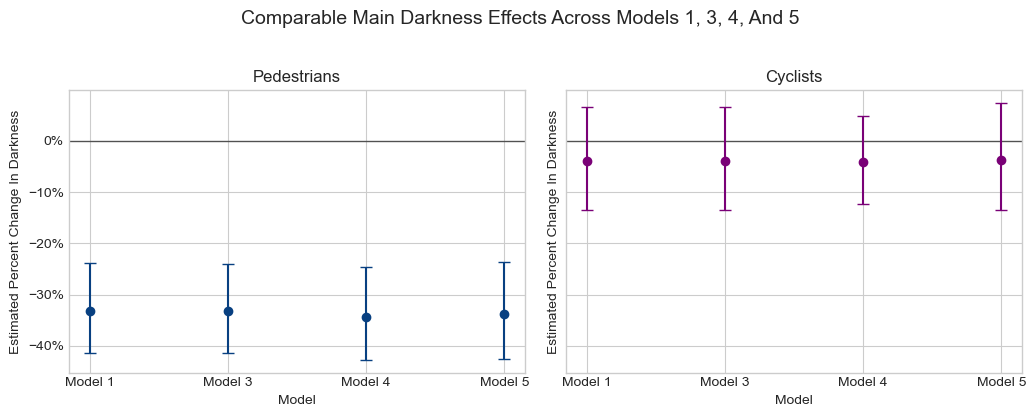

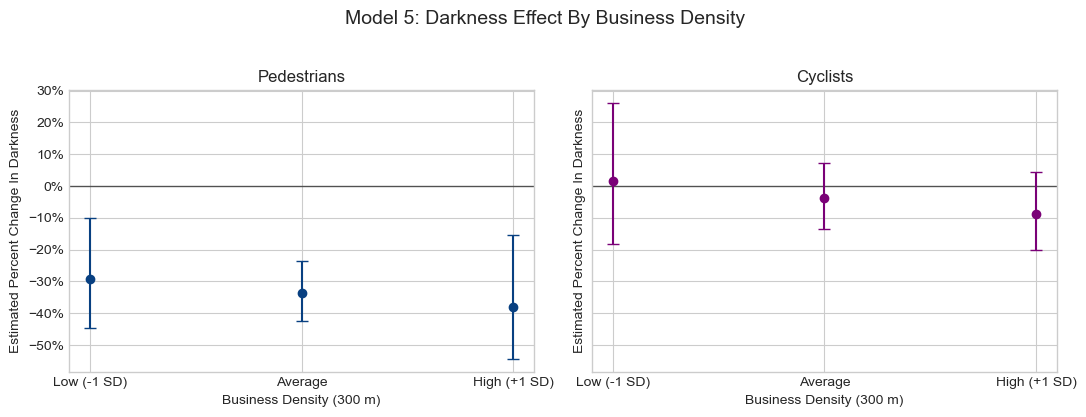

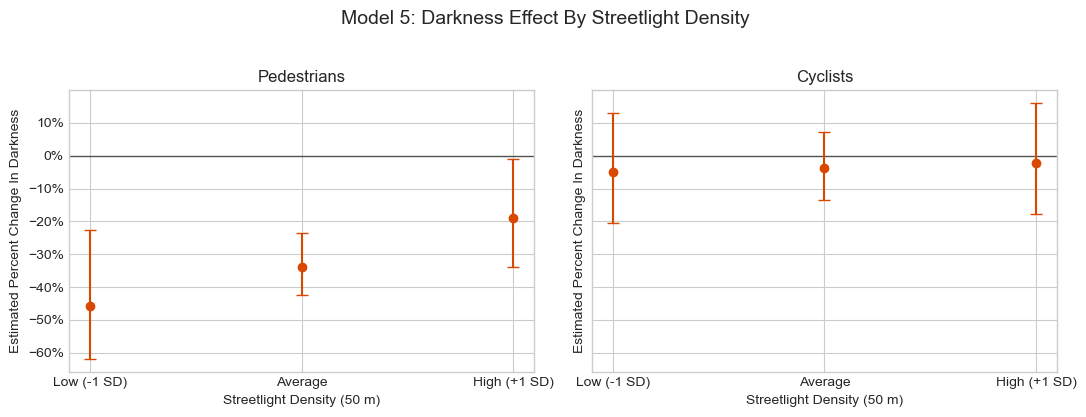

Saved figures to:
glm_model5_main_darkness_effects.png
glm_model5_business_heterogeneity.png
glm_model5_streetlight_heterogeneity.png


In [13]:
# ── Model 5 Visualisations ─────────────────────────────────────────────────
# Style matches Cell 16 (Models 1–4 figures): 1×2 side-by-side error-bar plots

# --- Business density moderation (streetlights held at mean = 0) ---
model5_biz_rows = []
for outcome in ['ped', 'cyc']:
    result = model_results[('Model 5', outcome)]['result']
    cov = result.cov_params()
    idx = list(result.params.index)
    for x, label in [(-1.0, 'Low (-1 SD)'), (0.0, 'Average'), (1.0, 'High (+1 SD)')]:
        w = np.zeros(len(idx))
        w[idx.index('Dark')] = 1.0
        w[idx.index('Dark:businesses_z')] = x
        est = float(np.dot(w, result.params.values))
        var = float(w @ cov.values @ w)
        se = float(np.sqrt(max(var, 0)))
        lo = est - 1.96 * se
        hi = est + 1.96 * se
        model5_biz_rows.append({
            'outcome': 'Pedestrians' if outcome == 'ped' else 'Cyclists',
            'level': label,
            'pct': coef_percent_change(est),
            'ci_low_pct': coef_percent_change(lo),
            'ci_high_pct': coef_percent_change(hi),
        })
model5_biz_df = pd.DataFrame(model5_biz_rows)

# --- Streetlight density moderation (businesses held at mean = 0) ---
model5_sl_rows = []
for outcome in ['ped', 'cyc']:
    result = model_results[('Model 5', outcome)]['result']
    cov = result.cov_params()
    idx = list(result.params.index)
    for x, label in [(-1.0, 'Low (-1 SD)'), (0.0, 'Average'), (1.0, 'High (+1 SD)')]:
        w = np.zeros(len(idx))
        w[idx.index('Dark')] = 1.0
        w[idx.index('Dark:streetlights_z')] = x
        est = float(np.dot(w, result.params.values))
        var = float(w @ cov.values @ w)
        se = float(np.sqrt(max(var, 0)))
        lo = est - 1.96 * se
        hi = est + 1.96 * se
        model5_sl_rows.append({
            'outcome': 'Pedestrians' if outcome == 'ped' else 'Cyclists',
            'level': label,
            'pct': coef_percent_change(est),
            'ci_low_pct': coef_percent_change(lo),
            'ci_high_pct': coef_percent_change(hi),
        })
model5_sl_df = pd.DataFrame(model5_sl_rows)

# ── Figure 1: Main darkness effect for Models 1, 3, 4, 5 ──────────────────
model5_comparison_rows = []
for model_name in ['Model 1', 'Model 3', 'Model 4', 'Model 5']:
    for outcome in ['ped', 'cyc']:
        result = model_results[(model_name, outcome)]['result']
        stats = linear_combo_summary(result, {'Dark': 1.0})
        model5_comparison_rows.append({
            'model': model_name,
            'outcome': 'Pedestrians' if outcome == 'ped' else 'Cyclists',
            **stats,
        })
model5_comparison_df = pd.DataFrame(model5_comparison_rows)

model5_main_fig = fig_dir / 'glm_model5_main_darkness_effects.png'
model5_biz_fig = fig_dir / 'glm_model5_business_heterogeneity.png'
model5_sl_fig = fig_dir / 'glm_model5_streetlight_heterogeneity.png'

model_order_5 = ['Model 1', 'Model 3', 'Model 4', 'Model 5']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
for ax, outcome in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = model5_comparison_df[model5_comparison_df['outcome'] == outcome].copy()
    sub['x'] = [model_order_5.index(m) for m in sub['model']]
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    ax.errorbar(
        sub['x'],
        sub['pct'],
        yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
        fmt='o',
        capsize=4,
        color='#084081' if outcome == 'Pedestrians' else '#7a0177',
    )
    ax.set_xticks(range(len(model_order_5)))
    ax.set_xticklabels(model_order_5)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome)
    ax.set_xlabel('Model')
    ax.set_ylabel('Estimated Percent Change In Darkness')
fig.suptitle('Comparable Main Darkness Effects Across Models 1, 3, 4, And 5', y=1.03, fontsize=14)
plt.tight_layout()
fig.savefig(model5_main_fig, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# ── Figure 2: Business density heterogeneity (1×2, Pedestrians | Cyclists) ─
level_order = ['Low (-1 SD)', 'Average', 'High (+1 SD)']
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, outcome in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = model5_biz_df[model5_biz_df['outcome'] == outcome].copy()
    sub['x'] = [level_order.index(v) for v in sub['level']]
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    ax.errorbar(
        sub['x'],
        sub['pct'],
        yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
        fmt='o',
        capsize=4,
        color='#084081' if outcome == 'Pedestrians' else '#7a0177',
    )
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels(level_order)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome)
    ax.set_xlabel('Business Density (300 m)')
    ax.set_ylabel('Estimated Percent Change In Darkness')
fig.suptitle('Model 5: Darkness Effect By Business Density', y=1.03, fontsize=14)
plt.tight_layout()
fig.savefig(model5_biz_fig, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# ── Figure 3: Streetlight density heterogeneity (1×2, Pedestrians | Cyclists) ─
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, outcome in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = model5_sl_df[model5_sl_df['outcome'] == outcome].copy()
    sub['x'] = [level_order.index(v) for v in sub['level']]
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    ax.errorbar(
        sub['x'],
        sub['pct'],
        yerr=[sub['pct'] - sub['ci_low_pct'], sub['ci_high_pct'] - sub['pct']],
        fmt='o',
        capsize=4,
        color='#d94801',
    )
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels(level_order)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome)
    ax.set_xlabel('Streetlight Density (50 m)')
    ax.set_ylabel('Estimated Percent Change In Darkness')
fig.suptitle('Model 5: Darkness Effect By Streetlight Density', y=1.03, fontsize=14)
plt.tight_layout()
fig.savefig(model5_sl_fig, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved figures to:')
print(model5_main_fig)
print(model5_biz_fig)
print(model5_sl_fig)

## Targeted Pedestrian Follow-Up

The pedestrian result is already strong, widespread, and stable across models. So the goal here is not to re-prove that darkness affects walking. It is to make the result more useful for policy by answering two narrower questions:

- **when is the pedestrian darkness penalty strongest?**
- **which sensors appear to be hit hardest?**

A short built-environment check is also included to see whether the strongest pedestrian penalty lines up more with business density or streetlight availability.


In [14]:
# ── Pedestrian timing and severity follow-up ───────────────────────────
ped_hour_cluster = (
    analysis_df.groupby(['Cluster', 'hour', 'light_class'])['ped']
    .mean()
    .unstack()
    .reset_index()
)
ped_hour_cluster['raw_pct_change_dark_vs_day'] = 100 * (ped_hour_cluster['darkness'] / ped_hour_cluster['daylight'] - 1)
ped_hour_cluster_table = ped_hour_cluster.pivot(index='Cluster', columns='hour', values='raw_pct_change_dark_vs_day')

ped_sensor_adjusted_rows = []
for sensor_id, sensor_df in analysis_df.groupby('SensorNumber'):
    model_df = sensor_df[['ped', 'Dark', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm']].dropna().copy()
    if len(model_df) < 200 or model_df['Dark'].nunique() < 2:
        continue
    result = smf.glm(
        formula='ped ~ Dark + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm',
        data=model_df,
        family=sm.families.NegativeBinomial(),
    ).fit()
    ped_sensor_adjusted_rows.append({
        'SensorNumber': sensor_id,
        'adjusted_dark_pct': coef_percent_change(result.params['Dark']),
        'adjusted_dark_p_value': result.pvalues['Dark'],
    })

ped_sensor_adjusted = (
    pd.DataFrame(ped_sensor_adjusted_rows)
    .merge(analysis_df[['SensorNumber', 'Cluster']].drop_duplicates(), on='SensorNumber', how='left')
)
ped_sensor_summary = (
    ped_sensor_adjusted.groupby('Cluster')['adjusted_dark_pct']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

ped_context_rows = []
if ('Model 5', 'ped') in model_results:
    ped_m5 = model_results[('Model 5', 'ped')]['result']
    ped_context_rows.append({
        'dark_pct_at_mean_context': coef_percent_change(ped_m5.params['Dark']),
        'dark_x_businesses_pct_per_1sd': coef_percent_change(ped_m5.params['Dark:businesses_z']),
        'dark_x_businesses_p_value': ped_m5.pvalues['Dark:businesses_z'],
        'dark_x_streetlights_pct_per_1sd': coef_percent_change(ped_m5.params['Dark:streetlights_z']),
        'dark_x_streetlights_p_value': ped_m5.pvalues['Dark:streetlights_z'],
    })
ped_context_followup = pd.DataFrame(ped_context_rows)

display(Markdown("### Raw Pedestrian Darkness Change By Cluster And Hour"))
display(ped_hour_cluster_table.round(1))
display(Markdown("### Adjusted Pedestrian Sensor-Level Severity Summary"))
display(ped_sensor_summary.round(2))
display(Markdown("**Most negative adjusted pedestrian sensor effects:**"))
display(ped_sensor_adjusted.sort_values('adjusted_dark_pct').head(10).round(3))
display(Markdown("### Pedestrian Built-Environment Follow-Up From Model 5"))
display(ped_context_followup.round(3))


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

...

,Cluster,count,mean,median,min,max
0,Central,9,-25.86,-16.82,-85.08,-5.25
1,East,20,-25.95,-22.65,-66.90,-10.48
2,Outlier,8,-36.93,-36.27,-83.56,-0.94


**Most negative adjusted pedestrian sensor effects:**

,SensorNumber,adjusted_dark_pct,adjusted_dark_p_value,Cluster
2,4,-85.082,0.0,Central
5,8,-83.557,0.0,Outlier
16,22,-66.898,0.0,East
6,9,-59.063,0.0,Outlier
15,21,-43.089,0.0,East
4,7,-42.844,0.0,Outlier
35,103,-38.570,0.0,Central
33,47,-37.658,0.0,Outlier
13,19,-35.405,0.0,East
10,15,-34.882,0.0,Outlier


### Pedestrian Built-Environment Follow-Up From Model 5

,dark_pct_at_mean_context,dark_x_businesses_pct_per_1sd,dark_x_businesses_p_value,dark_x_streetlights_pct_per_1sd,dark_x_streetlights_p_value
0,-33.758,-6.256,0.597,22.246,0.118


### What The Pedestrian Follow-Up Adds

This smaller extension sharpens the policy meaning of the pedestrian result without changing the main conclusion.

**1. The pedestrian darkness penalty is strongest at commuter-transition hours across all clusters.**

The raw hour-by-cluster table shows the same broad timing pattern everywhere.

- `Central`: `-63.3%` at `05:00`, `-72.7%` at `06:00`, then still negative through `17:00-20:00`.
- `East`: `-36.6%` at `05:00`, `-55.0%` at `06:00`, and still around `-22%` to `-30%` in the evening.
- `Outlier`: `-57.4%` at `05:00`, `-76.4%` at `06:00`, and still roughly `-24%` to `-29%` in the evening.

So the timing story is very consistent: the biggest pedestrian darkness penalties appear in the morning commuter transition, but the evening effect is still clearly negative across the network.

**2. The pedestrian result is broad, but severity still varies enough to help prioritisation.**

At adjusted sensor level, the average darkness effect is similar across `Central` and `East` (both around `-26%`) and somewhat more negative in `Outlier` (about `-36.9%`). But within those clusters there are still especially severe sites.

The most negative adjusted pedestrian effects include:
- sensor `4` in `Central`: about `-85.1%`
- sensor `8` in `Outlier`: about `-83.6%`
- sensor `22` in `East`: about `-66.9%`

That means the pedestrian story is both network-wide and prioritisation-friendly: the council can justify broad action while still identifying the worst-affected corridors first.

**3. Built-environment follow-up gives only limited extra explanation for pedestrians.**

The pedestrian Model 5 follow-up keeps the main darkness effect large at about `-33.8%` (`p = 1.33e-08`). The `Dark × businesses` term is weak (`p = 0.597`), and the `Dark × streetlights` term is positive but not statistically strong (`p = 0.118`).

So the built-environment terms do not overturn the main pedestrian result. At most, they suggest that better streetlight availability could be worth practical attention, but the current evidence is much stronger for a broad pedestrian darkness barrier than for any one narrow moderator.

**Overall conclusion from the pedestrian policy deep-dive**

For walking, the policy message is now sharper rather than more complicated. Darkness appears to be a city-wide barrier, the penalty is strongest at the hours most relevant for commuting, and the sensor-level ranking can be used to prioritise which corridors to improve first.


## Pedestrian Timing And Weekend Follow-Up
The raw pedestrian tables suggested that the `05:00–06:00` darkness penalty might be materially stronger than the evening penalty. This section tests that formally while keeping the same mixed-hour identification strategy used elsewhere in the notebook.

A single pedestrian GLM is fitted with `Dark × Morning × Weekend`, where:
- `Morning = 1` for `05:00–06:00`
- `Weekend = 1` for Saturday and Sunday

This means the inference still comes from the same mixed-hour daylight-versus-darkness comparison, but now asks two sharper questions:
1. is the darkness penalty larger in the early morning than in the evening?
2. does that extra morning penalty weaken on weekends, which would be more consistent with a narrow commuting explanation?

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


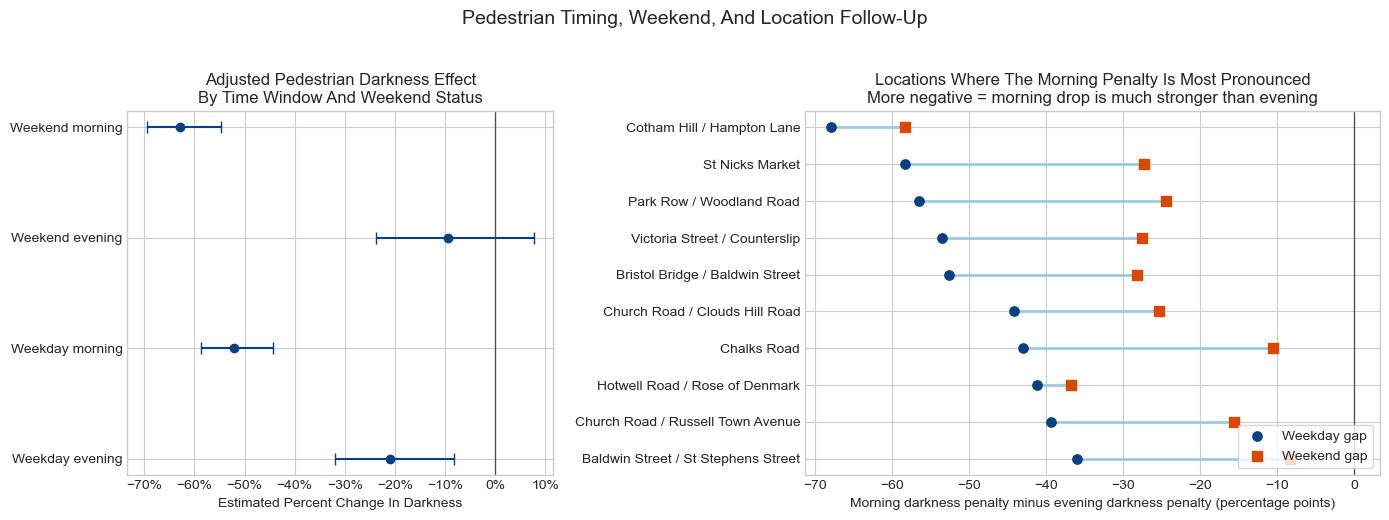

### Adjusted Pedestrian Darkness Effects By Time Window And Weekend Status

,term,percent_change,ci_low_pct,ci_high_pct,p_value
0,Weekday evening,-21.018,-31.991,-8.275,0.002
1,Weekday morning,-52.091,-58.766,-44.335,0.000
2,Weekend evening,-9.420,-23.831,7.718,0.263
3,Weekend morning,-62.833,-69.481,-54.737,0.000


### Formal Timing And Weekend Tests

,term,percent_change,p_value
0,Extra morning penalty on weekdays,-39.341,0.0
1,Weekend change in evening darkness effect,14.685,0.0
2,Weekend change in morning penalty,-32.356,0.0
3,Weekend vs weekday difference in morning darkn...,-22.422,0.0


### Raw Cluster-Level Morning Versus Evening Comparison

...

### Sensor Locations Where The Morning Penalty Is Strongest

,SensorNumber,Cluster,location_label,weekday_evening,weekday_morning,weekend_evening,weekend_morning,weekday_morning_minus_evening,weekend_morning_minus_evening
7,11,Outlier,Cotham Hill / Hampton Lane,-9.5,-77.5,-7.2,-65.6,-67.9,-58.4
0,1,Central,St Nicks Market,-14.5,-72.8,-11.3,-38.6,-58.3,-27.3
34,101,Central,Park Row / Woodland Road,-20.2,-76.7,-22.2,-46.6,-56.5,-24.4
9,14,Central,Victoria Street / Counterslip,-24.3,-77.8,-21.7,-49.3,-53.5,-27.6
3,5,Central,Bristol Bridge / Baldwin Street,-21.3,-73.9,-12.5,-40.7,-52.6,-28.2
27,40,East,Church Road / Clouds Hill Road,-31.6,-75.7,-34.9,-60.2,-44.2,-25.3
22,31,East,Chalks Road,-28.0,-70.9,-29.8,-40.3,-43.0,-10.4
4,7,Outlier,Hotwell Road / Rose of Denmark,-40.9,-82.1,-49.5,-86.3,-41.2,-36.8
21,29,East,Church Road / Russell Town Avenue,-33.9,-73.3,-36.8,-52.4,-39.4,-15.6
8,13,Central,Baldwin Street / St Stephens Street,-43.4,-79.4,-41.4,-49.7,-36.0,-8.3


### Weekend-Specific Built-Environment Follow-Up

,term,percent_change,p_value
0,Dark × businesses (weekday baseline),-7.341,0.525
1,Dark × streetlights (weekday baseline),23.601,0.101
2,Dark × Weekend × businesses,2.045,0.524
3,Dark × Weekend × streetlights,4.365,0.081


Saved figure: glm_pedestrian_timing_weekend.png


In [15]:
from scipy.stats import norm

# ── Pedestrian timing and weekend follow-up ───────────────────────────
analysis_df['Morning'] = analysis_df['hour'].isin([5, 6]).astype(int)
analysis_df['Weekend'] = analysis_df['is_weekend'].astype(int)

ped_timing_required = [
    'ped', 'Dark', 'Morning', 'Weekend', 'ped_lag1', 'ped_lag24',
    'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'
]
ped_timing_rhs = (
    'Dark + Dark:Morning + Dark:Weekend + Dark:Morning:Weekend '
    '+ ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) '
    '+ temp_c + wind_ms + rain_mm + C(SensorNumber)'
)
ped_timing_result, ped_timing_model_df, ped_timing_info = fit_nb_glm(
    analysis_df,
    'ped',
    ped_timing_rhs,
    ped_timing_required,
    'Pedestrian timing and weekend follow-up',
)


def linear_combo_full(result, weights, label):
    params = result.params
    cov = result.cov_params()
    idx = list(params.index)
    w = np.zeros(len(idx))
    for name, value in weights.items():
        if name in idx:
            w[idx.index(name)] = value
    est = float(np.dot(w, params.values))
    var = float(w @ cov.values @ w)
    se = float(np.sqrt(max(var, 0)))
    z = est / se if se > 0 else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z))) if se > 0 else np.nan
    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se
    return {
        'term': label,
        'coef': est,
        'std_err': se,
        'p_value': p_value,
        'percent_change': coef_percent_change(est),
        'ci_low_pct': coef_percent_change(ci_low),
        'ci_high_pct': coef_percent_change(ci_high),
    }


ped_timing_effects = pd.DataFrame([
    linear_combo_full(ped_timing_result, {'Dark': 1.0}, 'Weekday evening'),
    linear_combo_full(ped_timing_result, {'Dark': 1.0, 'Dark:Morning': 1.0}, 'Weekday morning'),
    linear_combo_full(ped_timing_result, {'Dark': 1.0, 'Dark:Weekend': 1.0}, 'Weekend evening'),
    linear_combo_full(ped_timing_result, {'Dark': 1.0, 'Dark:Morning': 1.0, 'Dark:Weekend': 1.0, 'Dark:Morning:Weekend': 1.0}, 'Weekend morning'),
])

ped_timing_tests = pd.DataFrame([
    linear_combo_full(ped_timing_result, {'Dark:Morning': 1.0}, 'Extra morning penalty on weekdays'),
    linear_combo_full(ped_timing_result, {'Dark:Weekend': 1.0}, 'Weekend change in evening darkness effect'),
    linear_combo_full(ped_timing_result, {'Dark:Morning:Weekend': 1.0}, 'Weekend change in morning penalty'),
    linear_combo_full(ped_timing_result, {'Dark:Weekend': 1.0, 'Dark:Morning:Weekend': 1.0}, 'Weekend vs weekday difference in morning darkness effect'),
])

ped_weekpart_raw = (
    analysis_df.groupby(['Cluster', 'Weekend', 'Morning', 'light_class'])['ped']
    .mean()
    .unstack()
    .reset_index()
)
ped_weekpart_raw['raw_pct_change_dark_vs_day'] = 100 * (ped_weekpart_raw['darkness'] / ped_weekpart_raw['daylight'] - 1)
ped_weekpart_cluster_table = ped_weekpart_raw.pivot_table(
    index='Cluster',
    columns=['Weekend', 'Morning'],
    values='raw_pct_change_dark_vs_day',
)
ped_weekpart_cluster_table.columns = [
    f"{'weekend' if is_weekend else 'weekday'}_{'morning' if is_morning else 'evening'}"
    for is_weekend, is_morning in ped_weekpart_cluster_table.columns
]
ped_weekpart_cluster_table['weekday_morning_minus_evening'] = (
    ped_weekpart_cluster_table['weekday_morning'] - ped_weekpart_cluster_table['weekday_evening']
)
ped_weekpart_cluster_table['weekend_morning_minus_evening'] = (
    ped_weekpart_cluster_table['weekend_morning'] - ped_weekpart_cluster_table['weekend_evening']
)

businesses_followup = pd.read_csv(BUSINESSES_PATH)[['SensorNumber', 'Businesses_within_300m']]
streetlights_followup = pd.read_csv(STREETLIGHT_PATH)[['SensorNumber', 'streetlights_50m']]
ped_weekend_context_df = (
    analysis_df
    .merge(businesses_followup, on='SensorNumber', how='left')
    .merge(streetlights_followup, on='SensorNumber', how='left')
)
ped_context_sensor = (
    ped_weekend_context_df[['SensorNumber', 'Businesses_within_300m', 'streetlights_50m']]
    .drop_duplicates('SensorNumber')
)
ped_weekend_context_df['businesses_z'] = (
    ped_weekend_context_df['Businesses_within_300m'] - ped_context_sensor['Businesses_within_300m'].mean()
) / ped_context_sensor['Businesses_within_300m'].std()
ped_weekend_context_df['streetlights_z'] = (
    ped_weekend_context_df['streetlights_50m'] - ped_context_sensor['streetlights_50m'].mean()
) / ped_context_sensor['streetlights_50m'].std()

ped_weekend_context_required = [
    'ped', 'Dark', 'Morning', 'Weekend', 'businesses_z', 'streetlights_z',
    'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'
]
ped_weekend_context_rhs = (
    'Dark + Dark:Morning + Dark:Weekend + Dark:Morning:Weekend '
    '+ Dark:businesses_z + Dark:streetlights_z '
    '+ Dark:Weekend:businesses_z + Dark:Weekend:streetlights_z '
    '+ ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) '
    '+ temp_c + wind_ms + rain_mm + C(SensorNumber)'
)
ped_weekend_context_result, ped_weekend_context_model_df, ped_weekend_context_info = fit_nb_glm(
    ped_weekend_context_df,
    'ped',
    ped_weekend_context_rhs,
    ped_weekend_context_required,
    'Pedestrian weekend context follow-up',
)
ped_weekend_context_terms = pd.DataFrame([
    term_row(ped_weekend_context_result, 'Dark:businesses_z', 'Dark × businesses (weekday baseline)'),
    term_row(ped_weekend_context_result, 'Dark:streetlights_z', 'Dark × streetlights (weekday baseline)'),
    term_row(ped_weekend_context_result, 'Dark:Weekend:businesses_z', 'Dark × Weekend × businesses'),
    term_row(ped_weekend_context_result, 'Dark:Weekend:streetlights_z', 'Dark × Weekend × streetlights'),
])

ped_sensor_weekpart = (
    analysis_df.groupby(['SensorNumber', 'Cluster', 'Weekend', 'Morning', 'light_class'])['ped']
    .mean()
    .unstack()
    .reset_index()
)
ped_sensor_weekpart['pct_dark_vs_day'] = 100 * (ped_sensor_weekpart['darkness'] / ped_sensor_weekpart['daylight'] - 1)
ped_sensor_weekpart = ped_sensor_weekpart.pivot_table(
    index=['SensorNumber', 'Cluster'],
    columns=['Weekend', 'Morning'],
    values='pct_dark_vs_day',
).reset_index()
ped_sensor_weekpart.columns = [
    'SensorNumber',
    'Cluster',
    'weekday_evening',
    'weekday_morning',
    'weekend_evening',
    'weekend_morning',
]
ped_sensor_weekpart['weekday_morning_minus_evening'] = ped_sensor_weekpart['weekday_morning'] - ped_sensor_weekpart['weekday_evening']
ped_sensor_weekpart['weekend_morning_minus_evening'] = ped_sensor_weekpart['weekend_morning'] - ped_sensor_weekpart['weekend_evening']

named_locations = pd.read_csv(Path('..') / 'reports' / 'cctv_with_assigned_cluster.csv')[['FEATURE_LOCATION', 'latitude', 'longitude']].drop_duplicates()
named_locations = named_locations.rename(columns={'FEATURE_LOCATION': 'location', 'latitude': 'location_lat', 'longitude': 'location_lon'})
named_locations['location'] = (
    named_locations['location']
    .fillna('')
    .astype(str)
    .str.replace('\r', ' ', regex=False)
    .str.replace('\n', ' ', regex=False)
    .str.strip()
)
named_locations = named_locations.loc[named_locations['location'] != ''].copy()

sensor_coords = analysis_df[['SensorNumber', 'Latitude', 'Longitude']].drop_duplicates('SensorNumber')


def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def nearest_named_location(sensor_row):
    distances = haversine_m(
        sensor_row['Latitude'],
        sensor_row['Longitude'],
        named_locations['location_lat'].to_numpy(),
        named_locations['location_lon'].to_numpy(),
    )
    best_idx = int(np.argmin(distances))
    return pd.Series({
        'nearest_named_location': named_locations.iloc[best_idx]['location'],
        'distance_to_named_location_m': float(distances[best_idx]),
    })


sensor_named_locations = pd.concat(
    [sensor_coords.reset_index(drop=True), sensor_coords.apply(nearest_named_location, axis=1)],
    axis=1,
)


def shorten_location(label):
    if pd.isna(label):
        return np.nan
    label = str(label).strip()
    if ' - ' in label:
        label = label.split(' - ')[0]
    if ',' in label:
        label = label.split(',')[0]
    label = ' '.join(label.split())
    return label


manual_location_labels = {
    1: 'St Nicks Market',
    5: 'Bristol Bridge / Baldwin Street',
    7: 'Hotwell Road / Rose of Denmark',
    11: 'Cotham Hill / Hampton Lane',
    13: 'Baldwin Street / St Stephens Street',
    14: 'Victoria Street / Counterslip',
    29: 'Church Road / Russell Town Avenue',
    31: 'Chalks Road',
    40: 'Church Road / Clouds Hill Road',
    101: 'Park Row / Woodland Road',
}


def readable_location_label(row):
    sensor_id = int(row['SensorNumber'])
    if sensor_id in manual_location_labels:
        return manual_location_labels[sensor_id]
    nearest = shorten_location(row.get('nearest_named_location'))
    if isinstance(nearest, str) and nearest and nearest.lower() != 'nan':
        return nearest
    return f"{row['Cluster']} cluster location"


ped_morning_hotspots = (
    ped_sensor_weekpart
    .merge(sensor_named_locations[['SensorNumber', 'nearest_named_location']], on='SensorNumber', how='left')
    .sort_values('weekday_morning_minus_evening')
    .head(10)
    .copy()
)
ped_morning_hotspots['plot_label'] = ped_morning_hotspots.apply(readable_location_label, axis=1)
ped_morning_hotspots['location_label'] = ped_morning_hotspots['plot_label']

ped_timing_fig = fig_dir / 'glm_pedestrian_timing_weekend.png'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.0, 1.35]})

# Left panel: adjusted timing/weekend effects
left = ped_timing_effects.copy()
left_order = ['Weekday evening', 'Weekday morning', 'Weekend evening', 'Weekend morning']
left['y'] = [left_order.index(v) for v in left['term']]
left = left.sort_values('y', ascending=False)
axes[0].axvline(0, color='black', linewidth=1, alpha=0.6)
axes[0].errorbar(
    left['percent_change'],
    left['y'],
    xerr=[left['percent_change'] - left['ci_low_pct'], left['ci_high_pct'] - left['percent_change']],
    fmt='o',
    capsize=4,
    color='#084081',
)
axes[0].set_yticks(left['y'])
axes[0].set_yticklabels(left['term'])
axes[0].xaxis.set_major_formatter(PercentFormatter())
axes[0].set_xlabel('Estimated Percent Change In Darkness')
axes[0].set_title('Adjusted Pedestrian Darkness Effect\nBy Time Window And Weekend Status')

# Right panel: sensor hotspots for the morning-evening gap
right = ped_morning_hotspots.copy().iloc[::-1].reset_index(drop=True)
right['y'] = np.arange(len(right))
axes[1].axvline(0, color='black', linewidth=1, alpha=0.6)
for _, row in right.iterrows():
    axes[1].plot(
        [row['weekday_morning_minus_evening'], row['weekend_morning_minus_evening']],
        [row['y'], row['y']],
        color='#9ecae1',
        linewidth=2,
        zorder=1,
    )
axes[1].scatter(right['weekday_morning_minus_evening'], right['y'], color='#084081', s=45, label='Weekday gap', zorder=2)
axes[1].scatter(right['weekend_morning_minus_evening'], right['y'], color='#d94801', s=45, marker='s', label='Weekend gap', zorder=3)
axes[1].set_yticks(right['y'])
axes[1].set_yticklabels(right['plot_label'])
axes[1].set_xlabel('Morning darkness penalty minus evening darkness penalty (percentage points)')
axes[1].set_title('Locations Where The Morning Penalty Is Most Pronounced\nMore negative = morning drop is much stronger than evening')
axes[1].legend(loc='lower right', frameon=True)

fig.suptitle('Pedestrian Timing, Weekend, And Location Follow-Up', y=1.03, fontsize=14)
plt.tight_layout()
fig.savefig(ped_timing_fig, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

display(Markdown('### Adjusted Pedestrian Darkness Effects By Time Window And Weekend Status'))
display(ped_timing_effects[['term', 'percent_change', 'ci_low_pct', 'ci_high_pct', 'p_value']].round(3))

display(Markdown('### Formal Timing And Weekend Tests'))
display(ped_timing_tests[['term', 'percent_change', 'p_value']].round(3))

display(Markdown('### Raw Cluster-Level Morning Versus Evening Comparison'))
display(ped_weekpart_cluster_table.round(1))

display(Markdown('### Sensor Locations Where The Morning Penalty Is Strongest'))
display(ped_morning_hotspots[['SensorNumber', 'Cluster', 'location_label', 'weekday_evening', 'weekday_morning', 'weekend_evening', 'weekend_morning', 'weekday_morning_minus_evening', 'weekend_morning_minus_evening']].round(1))

display(Markdown('### Weekend-Specific Built-Environment Follow-Up'))
display(ped_weekend_context_terms[['term', 'percent_change', 'p_value']].round(3))

print('Saved figure:', ped_timing_fig)


### What The Timing And Weekend Follow-Up Adds
This follow-up shows that the stronger early-morning pedestrian penalty is real after adjustment. The estimated darkness effect is **-21.0%** on **weekday evenings**, **-52.1%** on **weekday mornings**, **-9.4%** on **weekend evenings**, and **-62.8%** on **weekend mornings**. The extra morning penalty on weekdays is statistically strong (`Dark:Morning p = 2.18e-08`), and the total morning darkness effect is **more negative on weekends than on weekdays** (`Dark:Weekend + Dark:Morning:Weekend p = 1.37e-04`).

That changes the interpretation. If the `05:00–06:00` effect were mainly a narrow weekday commuting pattern, we would expect the morning penalty to weaken on weekends. The opposite appears here: the evening penalty softens on weekends, but the morning penalty becomes even more severe. The strongest morning-sensitive sensors are also not concentrated in obvious leisure locations. They cluster near **St Nicks Market**, **Bristol Bridge / Baldwin Street**, **Victoria Street / Counterslip**, **Park Row / Woodland Road**, and the **Church Road / Chalks Road** east Bristol corridor. That combination points toward a broader early-day walking deterrent in darkness, affecting access to central links, mixed-use destinations, and corridor routes rather than only weekday commuting.

The weekend-specific built-environment extension does not materially change that conclusion. `Dark × Weekend × businesses_z` was weak (`p = 0.524`), while `Dark × Weekend × streetlights_z` was only suggestive rather than conventionally strong (`p = 0.081`). So the clearest supported finding is still the timing pattern itself: early-morning darkness is especially unfavourable for walking, and that remains true even on weekends.

## Deeper Cyclist Follow-Up

The pooled cyclist result is weak, but the previous models suggest that this is because cyclist responses vary sharply by place and context rather than because darkness is irrelevant. The follow-up checks below dig into three layers of that heterogeneity:

- **sensor-level cyclist darkness effects**
- **hour-by-cluster cyclist patterns**
- **within-cluster safety and built-environment follow-up**

These are exploratory analyses. They are useful for understanding *why* the pooled cyclist effect is weak, but they should be interpreted more cautiously than the main four-model ladder.


In [16]:
# ── Sensor-level cyclist darkness effects ───────────────────────────────
sensor_cyclist_raw = (
    analysis_df.groupby(['SensorNumber', 'Cluster', 'light_class'])['cyc']
    .mean()
    .unstack()
    .reset_index()
)
sensor_cyclist_raw['raw_pct_change_dark_vs_day'] = 100 * (sensor_cyclist_raw['darkness'] / sensor_cyclist_raw['daylight'] - 1)

sensor_cyclist_adjusted_rows = []
for sensor_id, sensor_df in analysis_df.groupby('SensorNumber'):
    model_df = sensor_df[['cyc', 'Dark', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm']].dropna().copy()
    if len(model_df) < 200 or model_df['Dark'].nunique() < 2:
        continue
    result = smf.glm(
        formula='cyc ~ Dark + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm',
        data=model_df,
        family=sm.families.NegativeBinomial(),
    ).fit()
    sensor_cyclist_adjusted_rows.append({
        'SensorNumber': sensor_id,
        'adjusted_dark_coef': result.params['Dark'],
        'adjusted_dark_pct': coef_percent_change(result.params['Dark']),
        'adjusted_dark_p_value': result.pvalues['Dark'],
    })

sensor_cyclist_adjusted = (
    pd.DataFrame(sensor_cyclist_adjusted_rows)
    .merge(analysis_df[['SensorNumber', 'Cluster']].drop_duplicates(), on='SensorNumber', how='left')
)

sensor_cyclist_summary = (
    sensor_cyclist_adjusted.groupby('Cluster')['adjusted_dark_pct']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

display(Markdown("### Sensor-Level Cyclist Darkness Effects"))
display(sensor_cyclist_summary.round(2))
display(Markdown("**Most negative adjusted sensor-level cyclist effects:**"))
display(sensor_cyclist_adjusted.sort_values('adjusted_dark_pct').head(8).round(3))
display(Markdown("**Most positive adjusted sensor-level cyclist effects:**"))
display(sensor_cyclist_adjusted.sort_values('adjusted_dark_pct', ascending=False).head(8).round(3))

# ── Hour-by-cluster raw cyclist patterns ───────────────────────────────
cyclist_hour_cluster = (
    analysis_df.groupby(['Cluster', 'hour', 'light_class'])['cyc']
    .mean()
    .unstack()
    .reset_index()
)
cyclist_hour_cluster['raw_pct_change_dark_vs_day'] = 100 * (cyclist_hour_cluster['darkness'] / cyclist_hour_cluster['daylight'] - 1)
cyclist_hour_cluster_table = cyclist_hour_cluster.pivot(index='Cluster', columns='hour', values='raw_pct_change_dark_vs_day')

display(Markdown("### Raw Cyclist Darkness Change By Cluster And Hour"))
display(cyclist_hour_cluster_table.round(1))

# ── Within-cluster safety and context follow-up ───────────────────────
businesses_raw = pd.read_csv(BUSINESSES_PATH)[['SensorNumber', 'Businesses_within_300m']]
streetlight_raw = pd.read_csv(STREETLIGHT_PATH)[['SensorNumber', 'streetlights_50m']]
analysis_followup = (
    analysis_df
    .merge(businesses_raw, on='SensorNumber', how='left', suffixes=('', '_biz'))
    .merge(streetlight_raw, on='SensorNumber', how='left', suffixes=('', '_sl'))
)

sensor_followup_context = (
    analysis_followup[['SensorNumber', 'safety_after_dark_pct', 'Businesses_within_300m', 'streetlights_50m']]
    .drop_duplicates('SensorNumber')
)
safety_mean = sensor_followup_context['safety_after_dark_pct'].mean(skipna=True)
safety_std = sensor_followup_context['safety_after_dark_pct'].std(skipna=True)
biz_mean = sensor_followup_context['Businesses_within_300m'].mean(skipna=True)
biz_std = sensor_followup_context['Businesses_within_300m'].std(skipna=True)
sl_mean = sensor_followup_context['streetlights_50m'].mean(skipna=True)
sl_std = sensor_followup_context['streetlights_50m'].std(skipna=True)

analysis_followup['safety_z'] = (analysis_followup['safety_after_dark_pct'] - safety_mean) / safety_std
analysis_followup['businesses_z'] = (analysis_followup['Businesses_within_300m'] - biz_mean) / biz_std
analysis_followup['streetlights_z'] = (analysis_followup['streetlights_50m'] - sl_mean) / sl_std

safety_followup_rows = []
context_followup_rows = []
alignment_rows = []

for cluster_name in ['East', 'Outlier']:
    cluster_df = analysis_followup.loc[analysis_followup['Cluster'] == cluster_name].copy()

    safety_cols = ['cyc', 'Dark', 'safety_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber']
    safety_model_df = cluster_df[safety_cols].dropna().copy()
    safety_result = smf.glm(
        formula='cyc ~ Dark + Dark:safety_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        data=safety_model_df,
        family=sm.families.NegativeBinomial(),
    ).fit(cov_type='cluster', cov_kwds={'groups': safety_model_df['SensorNumber'].values})

    dark_beta = safety_result.params['Dark']
    int_beta = safety_result.params['Dark:safety_z']
    safety_followup_rows.append({
        'Cluster': cluster_name,
        'n_sensors': safety_model_df['SensorNumber'].nunique(),
        'dark_pct_at_mean_safety': coef_percent_change(dark_beta),
        'dark_x_safety_pct_per_1sd': coef_percent_change(int_beta),
        'dark_x_safety_p_value': safety_result.pvalues['Dark:safety_z'],
        'dark_pct_low_safety': coef_percent_change(dark_beta - int_beta),
        'dark_pct_high_safety': coef_percent_change(dark_beta + int_beta),
    })

    context_cols = ['cyc', 'Dark', 'businesses_z', 'streetlights_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber']
    context_model_df = cluster_df[context_cols].dropna().copy()
    context_result = smf.glm(
        formula='cyc ~ Dark + Dark:businesses_z + Dark:streetlights_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
        data=context_model_df,
        family=sm.families.NegativeBinomial(),
    ).fit(cov_type='cluster', cov_kwds={'groups': context_model_df['SensorNumber'].values})

    context_followup_rows.append({
        'Cluster': cluster_name,
        'n_sensors': context_model_df['SensorNumber'].nunique(),
        'dark_pct_at_mean_context': coef_percent_change(context_result.params['Dark']),
        'dark_x_businesses_pct_per_1sd': coef_percent_change(context_result.params['Dark:businesses_z']),
        'dark_x_businesses_p_value': context_result.pvalues['Dark:businesses_z'],
        'dark_x_streetlights_pct_per_1sd': coef_percent_change(context_result.params['Dark:streetlights_z']),
        'dark_x_streetlights_p_value': context_result.pvalues['Dark:streetlights_z'],
    })

    align_df = (
        cluster_df[['SensorNumber', 'safety_after_dark_pct', 'Businesses_within_300m', 'streetlights_50m']]
        .drop_duplicates('SensorNumber')
    )
    alignment_rows.append({
        'Cluster': cluster_name,
        'corr_safety_businesses': align_df['safety_after_dark_pct'].corr(align_df['Businesses_within_300m']),
        'corr_safety_streetlights': align_df['safety_after_dark_pct'].corr(align_df['streetlights_50m']),
    })

cyclist_safety_followup = pd.DataFrame(safety_followup_rows)
cyclist_context_followup = pd.DataFrame(context_followup_rows)
cyclist_alignment_followup = pd.DataFrame(alignment_rows)

display(Markdown("### Within-Cluster Cyclist Safety Follow-Up"))
display(cyclist_safety_followup.round(3))
display(Markdown("### Within-Cluster Cyclist Business And Streetlight Follow-Up"))
display(cyclist_context_followup.round(3))
display(Markdown("### How Strongly Safety Lines Up With Other Context Variables"))
display(cyclist_alignment_followup.round(3))


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa

...

,Cluster,n_sensors,dark_pct_at_mean_safety,dark_x_safety_pct_per_1sd,dark_x_safety_p_value,dark_pct_low_safety,dark_pct_high_safety
0,East,20,-8.038,-18.293,0.001,12.551,-24.861
1,Outlier,8,53.960,-34.681,0.000,135.705,0.565


### Within-Cluster Cyclist Business And Streetlight Follow-Up

,Cluster,n_sensors,dark_pct_at_mean_context,dark_x_businesses_pct_per_1sd,dark_x_businesses_p_value,dark_x_streetlights_pct_per_1sd,dark_x_streetlights_p_value
0,East,20,0.375,4.688,0.509,-5.753,0.458
1,Outlier,8,-87.706,-94.717,0.051,47.390,0.161


### How Strongly Safety Lines Up With Other Context Variables

,Cluster,corr_safety_businesses,corr_safety_streetlights
0,East,0.475,0.502
1,Outlier,0.715,-0.371


### What The Cyclist Follow-Up Adds

These deeper checks make the cyclist story much clearer.

**1. The cyclist heterogeneity is real at sensor level, not just at cluster-average level.**

- In `Central`, the adjusted sensor-level cyclist darkness effects are consistently negative, with a mean of about `-22.8%` and values ranging from about `-52.6%` to `-8.2%`.
- In `East`, the adjusted effects are centred much closer to zero, with a mean of about `+1.1%` but a wide range from about `-38.1%` to `+53.3%`.
- In `Outlier`, the spread is even larger, from about `-53.7%` to `+124.9%`.

So the weak pooled cyclist result is not hiding one clean city-wide cyclist effect. It is averaging over genuinely different local patterns.

**2. The cluster differences are strongly tied to time of day.**

The raw hour-by-cluster table shows a very uneven pattern.

- `Central` is negative in every mixed hour, especially `05:00` (`-63.1%`) and `06:00` (`-72.1%`).
- `East` is close to flat or positive in most evening hours and only clearly negative at `06:00` (`-39.8%`).
- `Outlier` is positive in most mixed hours and almost flat at `06:00` (`-0.2%`).

That means the cyclist pooled effect washes together very different hour-specific behaviours. The strongest cyclist darkness response is concentrated in particular places and times rather than spread evenly across the network.

**3. The safety interaction does not disappear when `East` and `Outlier` are analysed separately.**

- In `East`, the cyclist darkness effect at mean safety is about `-8.0%`, and the `Dark × safety` interaction remains negative and statistically strong (`p = 0.0014`). Moving one standard deviation up in safety makes the fitted darkness effect more negative.
- In `Outlier`, the same interaction is even stronger (`p = 2.28e-09`), though the sample is much smaller and more heterogeneous.

This is important because it shows the cyclist safety pattern is not only a `Central` versus `East` composition effect. However, it still should not be read as a simple causal safety story.

**4. Business density and streetlights do not fully explain the safety pattern, especially in `East`.**

- In `East`, the `Dark × businesses` and `Dark × streetlights` terms are both weak (`p = 0.509` and `p = 0.458`), even though `Dark × safety` is still significant.
- In `Outlier`, the `Dark × businesses` term is borderline (`p = 0.051`) and points toward a stronger darkness drop in more business-dense sites, but this is based on only `8` sensors and should be treated cautiously.

So the cyclist safety result looks broader than just “more businesses” or “more streetlights,” but it is still entangled with wider place context. That is reinforced by the sensor-level correlations: within `East`, safety is moderately correlated with both businesses (`r ≈ 0.47`) and streetlights (`r ≈ 0.50`), and within `Outlier`, safety is strongly correlated with businesses (`r ≈ 0.71`).

**Overall conclusion from the cyclist deep-dive**

The deeper analyses reinforce the main interpretation of the notebook. For walking, darkness behaves like a broad and fairly uniform barrier. For cycling, the more useful question is not “what is the one darkness effect?” but “which places and which hours show a negative darkness response, and what kind of environment do those places represent?”
